# Importing librarys and data

In [1]:
## Import librerias necesarias

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
from scipy.stats import spearmanr, kruskal, chi2_contingency
from itertools import combinations

#Import warnings

import warnings
warnings.filterwarnings('ignore')

In [2]:
#Import de nuestras funciones

from src.utils.funciones_eda import (
    significancia,
    anotar_barras,
    pct_reindex,
    plot_barras_dobles,
    COLORES,
    COLORES_SEG,
    COLORES_H1,
    COLORES_H2,
    COLORES_H3,
    COLORES_H4,
    COLORES_Q1
    )

In [4]:
#Definir nuestros datos como df

df = pd.read_csv("./src/data/Amazon Customer Behavior Survey.csv")

---
# Entendiendo el dataset

In [5]:
df

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Saveforlater_Frequency,Review_Left,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas
0,2023/06/04 1:28:19 PM GMT+5:30,23,Female,Few times a month,Beauty and Personal Care,Yes,Few times a week,Keyword,Multiple pages,1,...,Sometimes,Yes,Occasionally,Yes,2,Yes,1,1,Competitive prices,Reducing packaging waste
1,2023/06/04 2:30:44 PM GMT+5:30,23,Female,Once a month,Clothing and Fashion,Yes,Few times a month,Keyword,Multiple pages,1,...,Rarely,No,Heavily,Yes,2,Sometimes,3,2,Wide product selection,Reducing packaging waste
2,2023/06/04 5:04:56 PM GMT+5:30,24,Prefer not to say,Few times a month,Groceries and Gourmet Food;Clothing and Fashion,No,Few times a month,Keyword,Multiple pages,2,...,Rarely,No,Occasionally,No,4,No,3,3,Competitive prices,Product quality and accuracy
3,2023/06/04 5:13:00 PM GMT+5:30,24,Female,Once a month,Beauty and Personal Care;Clothing and Fashion;...,Sometimes,Few times a month,Keyword,First page,5,...,Sometimes,Yes,Heavily,Yes,3,Sometimes,3,4,Competitive prices,Product quality and accuracy
4,2023/06/04 5:28:06 PM GMT+5:30,22,Female,Less than once a month,Beauty and Personal Care;Clothing and Fashion,Yes,Few times a month,Filter,Multiple pages,1,...,Rarely,No,Heavily,Yes,4,Yes,2,2,Competitive prices,Product quality and accuracy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
597,2023/06/12 4:02:02 PM GMT+5:30,23,Female,Once a week,Beauty and Personal Care,Sometimes,Few times a week,categories,Multiple pages,4,...,Sometimes,Yes,Moderately,Sometimes,3,Sometimes,3,4,Competitive prices,Customer service responsiveness
598,2023/06/12 4:02:53 PM GMT+5:30,23,Female,Once a week,Clothing and Fashion,Sometimes,Few times a week,Filter,Multiple pages,3,...,Sometimes,Yes,Heavily,Sometimes,3,Sometimes,3,3,Product recommendations,Reducing packaging waste
599,2023/06/12 4:03:59 PM GMT+5:30,23,Female,Once a month,Beauty and Personal Care,Sometimes,Few times a week,categories,Multiple pages,3,...,Sometimes,Yes,Occasionally,Sometimes,3,Sometimes,2,3,Wide product selection,Product quality and accuracy
600,2023/06/12 9:57:20 PM GMT+5:30,23,Female,Few times a month,Beauty and Personal Care;Clothing and Fashion;...,Yes,Few times a month,Keyword,Multiple pages,1,...,Sometimes,No,Heavily,Yes,2,Yes,2,2,Wide product selection,Product quality and accuracy


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 602 entries, 0 to 601
Data columns (total 23 columns):
 #   Column                                  Non-Null Count  Dtype
---  ------                                  --------------  -----
 0   Timestamp                               602 non-null    str  
 1   age                                     602 non-null    int64
 2   Gender                                  602 non-null    str  
 3   Purchase_Frequency                      602 non-null    str  
 4   Purchase_Categories                     602 non-null    str  
 5   Personalized_Recommendation_Frequency   602 non-null    str  
 6   Browsing_Frequency                      602 non-null    str  
 7   Product_Search_Method                   600 non-null    str  
 8   Search_Result_Exploration               602 non-null    str  
 9   Customer_Reviews_Importance             602 non-null    int64
 10  Add_to_Cart_Browsing                    602 non-null    str  
 11  Cart_Completion_Frequency     

El timestamp está como string y lo queremos en DataTime. Lo tenemos en cuenta para después.

In [7]:
df.columns

Index(['Timestamp', 'age', 'Gender', 'Purchase_Frequency',
       'Purchase_Categories', 'Personalized_Recommendation_Frequency',
       'Browsing_Frequency', 'Product_Search_Method',
       'Search_Result_Exploration', 'Customer_Reviews_Importance',
       'Add_to_Cart_Browsing', 'Cart_Completion_Frequency',
       'Cart_Abandonment_Factors', 'Saveforlater_Frequency', 'Review_Left',
       'Review_Reliability', 'Review_Helpfulness',
       'Personalized_Recommendation_Frequency ', 'Recommendation_Helpfulness',
       'Rating_Accuracy ', 'Shopping_Satisfaction', 'Service_Appreciation',
       'Improvement_Areas'],
      dtype='str')

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,602.0,30.790698,10.193276,3.0,23.0,26.0,36.0,67.0
Customer_Reviews_Importance,602.0,2.480066,1.185226,1.0,1.0,3.0,3.0,5.0
Personalized_Recommendation_Frequency,602.0,2.699336,1.042028,1.0,2.0,3.0,3.0,5.0
Rating_Accuracy,602.0,2.672757,0.899744,1.0,2.0,3.0,3.0,5.0
Shopping_Satisfaction,602.0,2.463455,1.012152,1.0,2.0,2.0,3.0,5.0


Vemos que Personalized_Recomendation_Frequency, Parting_Accuracy y Shopping_Satisfaction tienes casi los mismos valores y comparten como mínimo y máximo el mismo número. Deducimos que seguramente sea de una encuesta en la que les hayan hecho elegir del 1 al 5. Podemos asignarles valores en la visualización. Lo tenemos en cuenta para después.

In [9]:
df["Personalized_Recommendation_Frequency"].value_counts()

Personalized_Recommendation_Frequency
No           251
Sometimes    229
Yes          122
Name: count, dtype: int64

In [10]:
df["Personalized_Recommendation_Frequency "].value_counts()

Personalized_Recommendation_Frequency 
3    240
2    169
1     80
4     78
5     35
Name: count, dtype: int64

Vemos que hay dos columnas con el mismo nombre pero con distintos. La primera se trata de si alguna vez has hecho una compra basandote en recomendaciones personalizadas de Amazon y la segunda que tan a menudo recibes recomendaciones personalizadas de Amazon. Lo tenemos en cuenta para después.

In [11]:
df.isnull().sum().sort_values(ascending=False)

Product_Search_Method                     2
age                                       0
Timestamp                                 0
Purchase_Frequency                        0
Purchase_Categories                       0
Personalized_Recommendation_Frequency     0
Gender                                    0
Browsing_Frequency                        0
Search_Result_Exploration                 0
Customer_Reviews_Importance               0
Add_to_Cart_Browsing                      0
Cart_Completion_Frequency                 0
Cart_Abandonment_Factors                  0
Saveforlater_Frequency                    0
Review_Left                               0
Review_Reliability                        0
Review_Helpfulness                        0
Personalized_Recommendation_Frequency     0
Recommendation_Helpfulness                0
Rating_Accuracy                           0
Shopping_Satisfaction                     0
Service_Appreciation                      0
Improvement_Areas               

In [12]:
df["Product_Search_Method"].unique()

<StringArray>
['Keyword', 'Filter', 'categories', 'others', nan]
Length: 5, dtype: str

In [13]:
df[df["Product_Search_Method"].isna()]

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Saveforlater_Frequency,Review_Left,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas
119,2023/06/06 2:07:12 PM GMT+5:30,21,Female,Once a month,Clothing and Fashion,Sometimes,Few times a week,NaN,Multiple pages,3,...,Often,No,Moderately,Sometimes,3,Sometimes,3,3,User-friendly website/app interface,Customer service responsiveness
382,2023/06/08 5:49:59 PM GMT+5:30,47,Female,Few times a month,Beauty and Personal Care;Clothing and Fashion;...,No,Multiple times a day,NaN,Multiple pages,1,...,Often,No,Moderately,No,2,No,3,2,Wide product selection,Shipping speed and reliability


Vemos que en Product_Search_Method hay nulos. Lo tenemos en cuenta para después.

In [14]:
df.age.describe()

count    602.000000
mean      30.790698
std       10.193276
min        3.000000
25%       23.000000
50%       26.000000
75%       36.000000
max       67.000000
Name: age, dtype: float64

In [15]:
df["age"].value_counts().sort_index().head(6)

age
3     1
12    1
15    2
16    5
17    4
18    7
Name: count, dtype: int64

Vemos que hay menores haciendo compras. Lo tenemos en cuenta para después, expecialmente el de 3 años.

In [16]:
df.Purchase_Frequency.unique()

<StringArray>
[     'Few times a month',           'Once a month', 'Less than once a month',
  'Multiple times a week',            'Once a week']
Length: 5, dtype: str

In [17]:
df.nunique()

Timestamp                                 601
age                                        50
Gender                                      4
Purchase_Frequency                          5
Purchase_Categories                        29
Personalized_Recommendation_Frequency       3
Browsing_Frequency                          4
Product_Search_Method                       4
Search_Result_Exploration                   2
Customer_Reviews_Importance                 5
Add_to_Cart_Browsing                        3
Cart_Completion_Frequency                   5
Cart_Abandonment_Factors                    4
Saveforlater_Frequency                      5
Review_Left                                 2
Review_Reliability                          5
Review_Helpfulness                          3
Personalized_Recommendation_Frequency       5
Recommendation_Helpfulness                  3
Rating_Accuracy                             5
Shopping_Satisfaction                       5
Service_Appreciation              

In [18]:
df["Purchase_Categories"].value_counts()

Purchase_Categories
Beauty and Personal Care                                                                            106
Clothing and Fashion                                                                                106
others                                                                                               48
Beauty and Personal Care;Clothing and Fashion                                                        46
Beauty and Personal Care;Clothing and Fashion;Home and Kitchen                                       42
Groceries and Gourmet Food;Beauty and Personal Care;Clothing and Fashion;Home and Kitchen;others     32
Clothing and Fashion;Home and Kitchen                                                                27
Home and Kitchen                                                                                     24
Beauty and Personal Care;Home and Kitchen                                                            21
Clothing and Fashion;Home and Kitchen;others

Nos preguntamos si podriamos encapsular algunas categorias o crear una nueva columna para una observación más exaustiva. Lo tenemos en cuenta para después.

##### Significado columnas

1. age = edad  
2. gender = género  
3. Purchase_Frequency = ¿Con qué frecuencia realizas compras en Amazon?  
4. Purchase_Categories = ¿Qué categorías de productos sueles comprar en Amazon?  
5. Personalized_Recommendation_Frequency = ¿Alguna vez has comprado un producto basándote en recomendaciones personalizadas de Amazon?  
6. Browsing_Frequency = ¿Con qué frecuencia navegas por el sitio web o la aplicación de Amazon?  
7. Product_Search_Method = ¿Cómo buscas productos en Amazon?  
8. Search_Result_Exploration = ¿Sueles explorar varias páginas de resultados de búsqueda o te quedas en la primera página?  
9. Customer_Reviews_Importance = ¿Qué importancia tienen las reseñas de clientes en tu proceso de toma de decisiones?  
10. Add_to_Cart_Browsing = ¿Añades productos a tu carrito mientras navegas por Amazon?  
11. Cart_Completion_Frequency = ¿Con qué frecuencia completas la compra después de añadir productos al carrito?  
12. Cart_Abandonment_Factors = ¿Qué factores influyen en tu decisión de abandonar una compra en el carrito?  
13. Saveforlater_Frequency = ¿Utilizas la función “Guardar para más tarde” de Amazon y, si es así, con qué frecuencia?  
14. Review_Left = ¿Alguna vez has dejado una reseña de un producto en Amazon?  
15. Review_Reliability = ¿Cuánto confías en las reseñas de productos al realizar una compra?  
16. Review_Helpfulness = ¿Encuentras información útil en las reseñas de otros clientes?  
17. Personalized_Recommendation_Frequency = ¿Con qué frecuencia recibes recomendaciones personalizadas de productos de Amazon?  
18. Recommendation_Helpfulness = ¿Te resultan útiles las recomendaciones?  
19. Rating_Accuracy = ¿Cómo calificarías la relevancia y precisión de las recomendaciones que recibes?  
20. Shopping_Satisfaction = ¿Qué tan satisfecho estás con tu experiencia general de compra en Amazon?  
21. Service_Appreciation = ¿Qué aspectos de los servicios de Amazon aprecias más?  
22. Improvement_Areas = ¿Hay áreas en las que crees que Amazon puede mejorar?  

In [19]:
for col in df.columns:
    print(f"{col}:",df[col].unique())

Timestamp: <StringArray>
['2023/06/04 1:28:19 PM GMT+5:30', '2023/06/04 2:30:44 PM GMT+5:30',
 '2023/06/04 5:04:56 PM GMT+5:30', '2023/06/04 5:13:00 PM GMT+5:30',
 '2023/06/04 5:28:06 PM GMT+5:30', '2023/06/04 6:01:59 PM GMT+5:30',
 '2023/06/04 6:31:41 PM GMT+5:30', '2023/06/04 7:13:12 PM GMT+5:30',
 '2023/06/04 7:23:21 PM GMT+5:30', '2023/06/04 7:33:12 PM GMT+5:30',
 ...
 '2023/06/12 3:56:57 PM GMT+5:30', '2023/06/12 3:57:52 PM GMT+5:30',
 '2023/06/12 3:59:10 PM GMT+5:30', '2023/06/12 3:59:59 PM GMT+5:30',
 '2023/06/12 4:00:56 PM GMT+5:30', '2023/06/12 4:02:02 PM GMT+5:30',
 '2023/06/12 4:02:53 PM GMT+5:30', '2023/06/12 4:03:59 PM GMT+5:30',
 '2023/06/12 9:57:20 PM GMT+5:30', '2023/06/16 9:16:05 AM GMT+5:30']
Length: 601, dtype: str
age: [23 24 22 21 20 25 16 64 29 19 26 32 30 40 36 31 47 54 58 53 28 55 62 27
 34 44 38 35 42 37 45 50 63 46 33 60 18 17 57 41 39 48 49 15 43 52  3 67
 56 12]
Gender: <StringArray>
['Female', 'Prefer not to say', 'Male', 'Others']
Length: 4, dtype: str
Pur

Fijarnos en el Search_Result_Exploration nos podria dar indicios de compraciones de precio o duda a la hora de comprar. Lo tenemos en cuenta para después.

Vemos resultados repetidos o incoherentes en Service_Appreciation. Lo tenemos en cuenta para después.

Vemos resultados repetidos, con espacios a final o incoherentes en Improvement_Areas. Lo tenemos en cuenta para después.

In [20]:
df.loc[df["Improvement_Areas"].isin(["UI", "Nil","Nothing"])]

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Saveforlater_Frequency,Review_Left,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas
41,2023/06/05 12:36:02 AM GMT+5:30,32,Male,Less than once a month,others,No,Rarely,Keyword,First page,1,...,Never,No,Moderately,Yes,1,No,4,1,Customer service,Nothing
156,2023/06/06 7:10:55 PM GMT+5:30,24,Male,Less than once a month,others,No,Few times a month,Keyword,Multiple pages,4,...,Sometimes,No,Occasionally,Yes,3,Yes,4,5,Wide product selection,Nil
190,2023/06/07 6:09:58 AM GMT+5:30,23,Male,Once a month,Clothing and Fashion;others,No,Few times a month,Keyword,Multiple pages,1,...,Often,Yes,Heavily,Yes,3,No,3,3,Competitive prices,UI


Ya que son pocas columnas pensamos en cambiar los valores abstractos a "Nothing" ya que así manejaremos mejor los datos.

In [21]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Timestamp,602,601,2023/06/07 11:47:44 AM GMT+5:30,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,602.0,NaN,NaN,NaN,30.790698,10.193276,3.0,23.0,26.0,36.0,67.0
Gender,602,4,Female,352,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Purchase_Frequency,602,5,Few times a month,203,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Purchase_Categories,602,29,Beauty and Personal Care,106,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Personalized_Recommendation_Frequency,602,3,No,251,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Browsing_Frequency,602,4,Few times a week,249,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Search_Method,600,4,categories,223,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Search_Result_Exploration,602,2,Multiple pages,442,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_Reviews_Importance,602.0,NaN,NaN,NaN,2.480066,1.185226,1.0,1.0,3.0,3.0,5.0


Finalmente creamos un diccionario para verlo mas fácil y rápido.

In [26]:
# Genera un data dictionary automático

# Dividimos los tipos según el tipo de analisis que haremos a continuación
def var_type(col):
    if pd.api.types.is_numeric_dtype(df[col]):
        return "numérica"
    elif pd.api.types.is_datetime64_any_dtype(df[col]):
        return "fecha"
    else:
        return "categórica"

data_dict = pd.DataFrame({
    "columna": df.columns,
    "tipo": [var_type(c) for c in df.columns],
    "dtype": df.dtypes.astype(str).values,
    "nulos_pct": (df.isnull().sum()),
    "unicos": df.nunique().values,
    "min": [df[c].min() if pd.api.types.is_numeric_dtype(df[c]) else None for c in df.columns],
    "max": [df[c].max() if pd.api.types.is_numeric_dtype(df[c]) else None for c in df.columns],
    "duplicados": [df[c].duplicated().sum() for c in df.columns]})
#data_dict.to_csv("data_dictionary.csv", index=False)
data_dict

,columna,tipo,dtype,nulos_pct,unicos,min,max,duplicados
Timestamp,Timestamp,categórica,str,0,601,NaN,NaN,1
age,age,numérica,int64,0,50,3.0,67.0,552
Gender,Gender,categórica,str,0,4,NaN,NaN,598
Purchase_Frequency,Purchase_Frequency,categórica,str,0,5,NaN,NaN,597
Purchase_Categories,Purchase_Categories,categórica,str,0,29,NaN,NaN,573
Personalized_Recommendation_Frequency,Personalized_Recommendation_Frequency,categórica,str,0,3,NaN,NaN,599
Browsing_Frequency,Browsing_Frequency,categórica,str,0,4,NaN,NaN,598
Product_Search_Method,Product_Search_Method,categórica,str,2,4,NaN,NaN,597
Search_Result_Exploration,Search_Result_Exploration,categórica,str,0,2,NaN,NaN,600
Customer_Reviews_Importance,Customer_Reviews_Importance,numérica,int64,0,5,1.0,5.0,597


---
# Limpieza dataset

In [27]:
# Convertir fechas en datetime
df["Timestamp"] = pd.to_datetime(df["Timestamp"], format="%Y/%m/%d %I:%M:%S %p GMT+5:30")

In [28]:
# Limpiamos los nulos de Product_Search_Method transformandolos en la moda
df["Product_Search_Method"] = df["Product_Search_Method"].fillna(df["Product_Search_Method"].mode()[0])

In [29]:
# Reasignamos otro nombre a la columna Personalized_Recommendation_Frequency 
df.rename(columns={"Personalized_Recommendation_Frequency": "Purchase_Based_on_Recommendations"}, inplace=True)

# Corregimos la columna Personalized_Recommendation_Frequency con espacio al final
df.rename(columns={"Personalized_Recommendation_Frequency ": "Personalized_Recommendation_Frequency"}, inplace=True)

In [30]:
# Correguimos la columna Rating_Accuracy
df.rename(columns={"Rating_Accuracy ": "Rating_Accuracy"}, inplace=True)

In [31]:
# Corregimos respuestas de Service_Appreciation quitando problemas de escritura y convirtiendo la . en la moda

df["Service_Appreciation"] = df["Service_Appreciation"].str.strip().str.capitalize().replace(".", df.Service_Appreciation.mode()[0])

In [32]:
# Corregimos respuestas de Improvement_Areas quitando problemas de escritura y convirtiendo a "Nothing" los datos incoherentes

df["Improvement_Areas"] = df["Improvement_Areas"].str.strip().str.capitalize().replace([".","Ui", "Nil"], "Nothing")

In [99]:
# Hacemos un binning en la edad/age

df["tramo_edad"] = pd.cut(df["age"],bins=[0, 17, 25, 35, 50, 65, 100],labels=["0-17","18-25", "26-35", "36-50", "51-65", "65+"]).astype(str)

In [35]:
df["tramo_edad"].value_counts().sort_index()

tramo_edad
0-17      13
18-25    262
26-35    168
36-50    130
51-65     27
65+        2
Name: count, dtype: int64

In [100]:
# Encodeamos ciertas columnas ya que mantienen un orden

ordinal_cols = {
    "Purchase_Frequency": ["Less than once a month", "Once a month", "Few times a month", "Once a week", "Multiple times a week"],
    "Browsing_Frequency": ["Rarely", "Few times a month", "Few times a week", "Multiple times a day"],
    "Cart_Completion_Frequency": ["Never", "Rarely", "Sometimes", "Often", "Always"],
    "Saveforlater_Frequency": ["Never", "Rarely", "Sometimes", "Often", "Always"],
    "Purchase_Based_on_Recommendations": ["No", "Sometimes", "Yes"],
    "Review_Reliability":["Never", "Rarely", "Occasionally", "Moderately", "Heavily"],
    "tramo_edad":["0-17", "18-25", "26-35", "36-50", "51-65", "65+"]
}

for col, order in ordinal_cols.items():
    df[col + "_enc"] = df[col].map({v: i+1 for i, v in enumerate(order)})

---
# Analysis

#### Analysis univariante

##### Númericas

In [107]:
columnas_numericas = [col for col in df.columns if var_type(col) == "numérica"]

In [38]:
def resumen_numerica(col):
    s = df[col]
    resumen = pd.DataFrame({
        "media":    [round(s.mean(), 3)],
        "mediana":  [round(s.median(), 3)],
        "moda":     [s.mode()[0]],
        "std":      [round(s.std(), 3)],
        "min":      [s.min()],
        "max":      [s.max()],
        "Q1":       [s.quantile(0.25)],
        "Q3":       [s.quantile(0.75)],
    }, index=[col])
    return resumen


pd.concat([resumen_numerica(c) for c in columnas_numericas])

,media,mediana,moda,std,min,max,Q1,Q3
age,30.791,26.0,23,10.193,3,67,23.0,36.0
Customer_Reviews_Importance,2.480,3.0,3,1.185,1,5,1.0,3.0
Personalized_Recommendation_Frequency,2.699,3.0,3,1.042,1,5,2.0,3.0
Rating_Accuracy,2.673,3.0,3,0.900,1,5,2.0,3.0
Shopping_Satisfaction,2.463,2.0,3,1.012,1,5,2.0,3.0
Purchase_Frequency_enc,2.782,3.0,3,1.231,1,5,2.0,4.0
Browsing_Frequency_enc,2.542,3.0,3,0.872,1,4,2.0,3.0
Cart_Completion_Frequency_enc,3.229,3.0,3,0.885,1,5,3.0,4.0
Saveforlater_Frequency_enc,3.106,3.0,3,1.066,1,5,3.0,4.0
Purchase_Based_on_Recommendations_enc,1.786,2.0,1,0.758,1,3,1.0,2.0


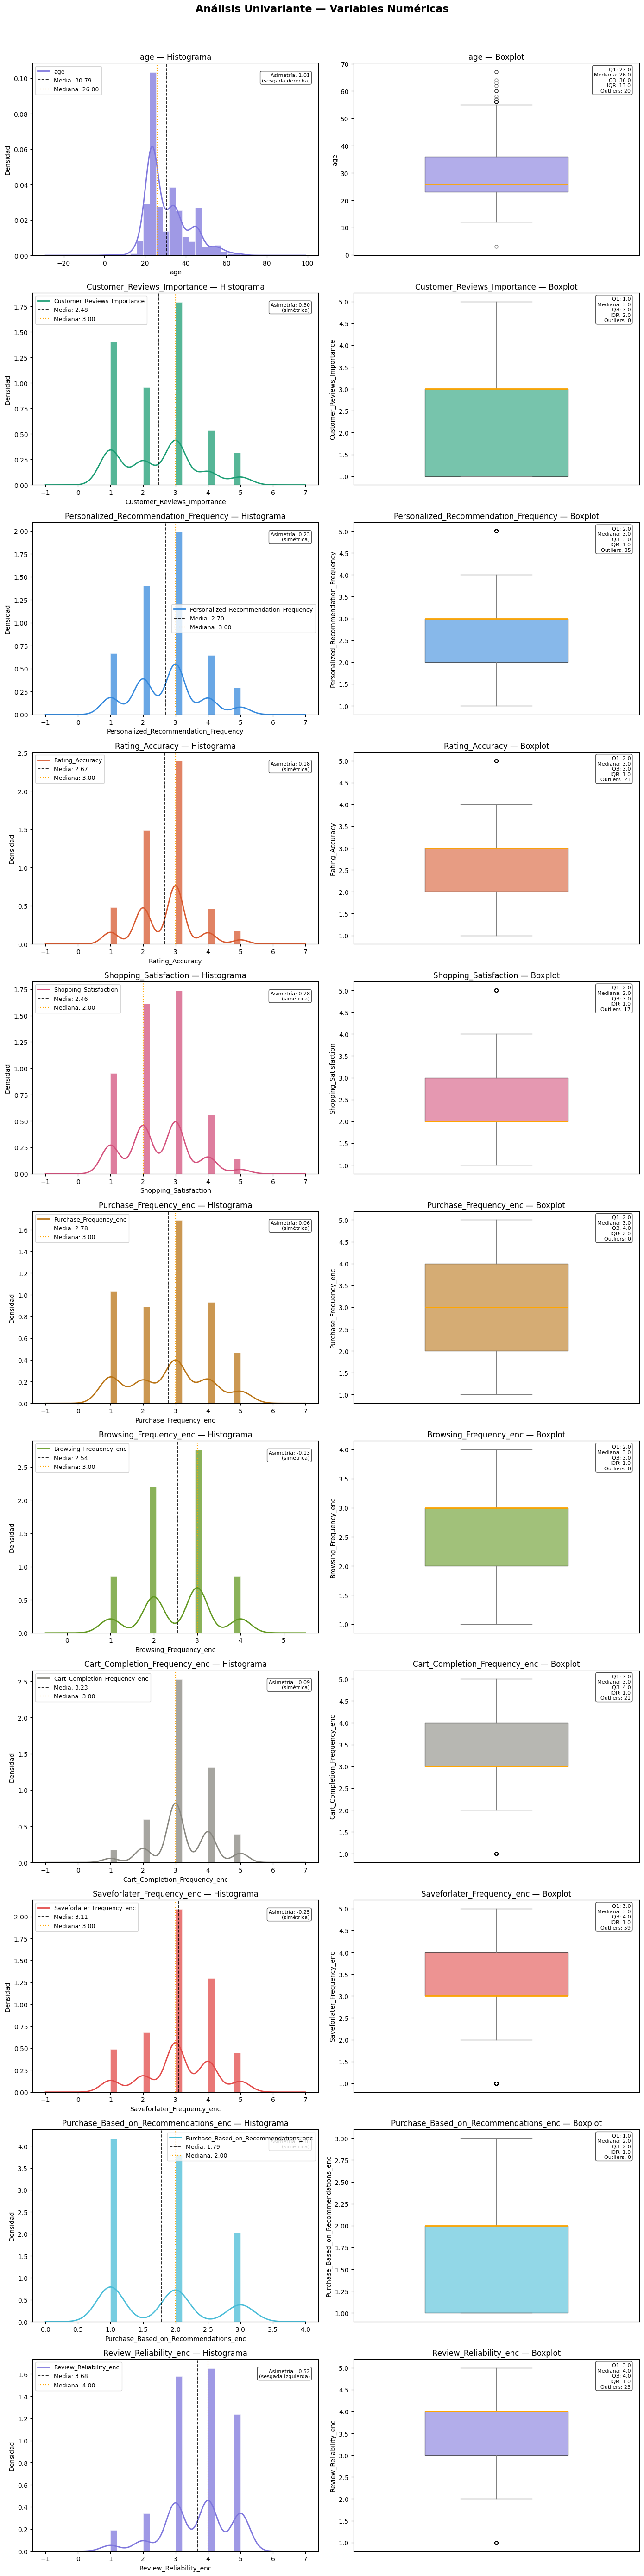

In [39]:
fig, axes = plt.subplots(len(columnas_numericas), 2, figsize=(14, 5 * len(columnas_numericas)))

for i, col in enumerate(columnas_numericas):
    s = df[col]
    color = COLORES[i % len(COLORES)]

    # Histograma
    ax1 = axes[i, 0]
    ax1.hist(s, bins=20, color=color, alpha=0.75, edgecolor="white", linewidth=0.5, density=True)
    s.plot.kde(ax=ax1, color=color, linewidth=2)
    ax1.axvline(s.mean(),   color="black",  linestyle="--", linewidth=1.2, label=f"Media: {s.mean():.2f}")
    ax1.axvline(s.median(), color="orange", linestyle=":",  linewidth=1.5, label=f"Mediana: {s.median():.2f}")
    ax1.set_title(f"{col} — Histograma")
    ax1.set_xlabel(col)
    ax1.set_ylabel("Densidad")
    ax1.legend(fontsize=9)

    # Texto tipo asimetría
    skew = s.skew()
    tipo_asim = "simétrica" if abs(skew) < 0.5 else ("sesgada derecha" if skew > 0 else "sesgada izquierda")
    ax1.text(0.97, 0.95, f"Asimetría: {skew:.2f}\n({tipo_asim})",
             transform=ax1.transAxes, ha="right", va="top", fontsize=8,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))

    # Boxplot
    ax2 = axes[i, 1]
    bp = ax2.boxplot(s, vert=True, patch_artist=True, widths=0.5,
                     boxprops=dict(facecolor=color, alpha=0.6),
                     medianprops=dict(color="orange", linewidth=2),
                     whiskerprops=dict(color="gray"),
                     capprops=dict(color="gray"),
                     flierprops=dict(marker="o", color=color, alpha=0.5, markersize=5))
    ax2.set_title(f"{col} — Boxplot")
    ax2.set_ylabel(col)
    ax2.set_xticks([])

    # Anotar estadísticos
    q1, q3, med = s.quantile(0.25), s.quantile(0.75), s.median()
    iqr = q3 - q1
    outliers = s[(s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)]
    ax2.text(0.97, 0.98,
             f"Q1: {q1:.1f}\nMediana: {med:.1f}\nQ3: {q3:.1f}\nIQR: {iqr:.1f}\nOutliers: {len(outliers)}",
             transform=ax2.transAxes, ha="right", va="top", fontsize=8,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))

plt.suptitle("Análisis Univariante — Variables Numéricas", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
#plt.savefig("src/img/univariante_numericas.png", bbox_inches="tight", dpi=150)
plt.show()

**Conclusiones — Variables Numéricas:**

- **age**: Media de 30.8 años con mediana en 26, lo que indica una distribución sesgada a la derecha. El 75% de los encuestados tiene menos de 36 años, confirmando una audiencia joven. El rango es amplio (3–67 años) pero los extremos son casos anómalos.

- **Customer_Reviews_Importance**: Media de 2.48 sobre 5, con distribución bimodal (picos en 1 y 3). Esto sugiere dos perfiles: usuarios que no confían en reseñas y usuarios con confianza moderada. Pocos usuarios le dan máxima importancia (5).

- **Rating_Accuracy**: Media de 2.67, concentrada en valores centrales (2–3). La distribución es aproximadamente simétrica, lo que indica una percepción moderada y homogénea de la precisión de las valoraciones.

- **Shopping_Satisfaction**: Media de 2.46 sobre 5, la más baja de todas las métricas. La mediana es 2, lo que indica que más de la mitad de los usuarios tiene una satisfacción baja. Hay margen de mejora claro en la experiencia de compra.

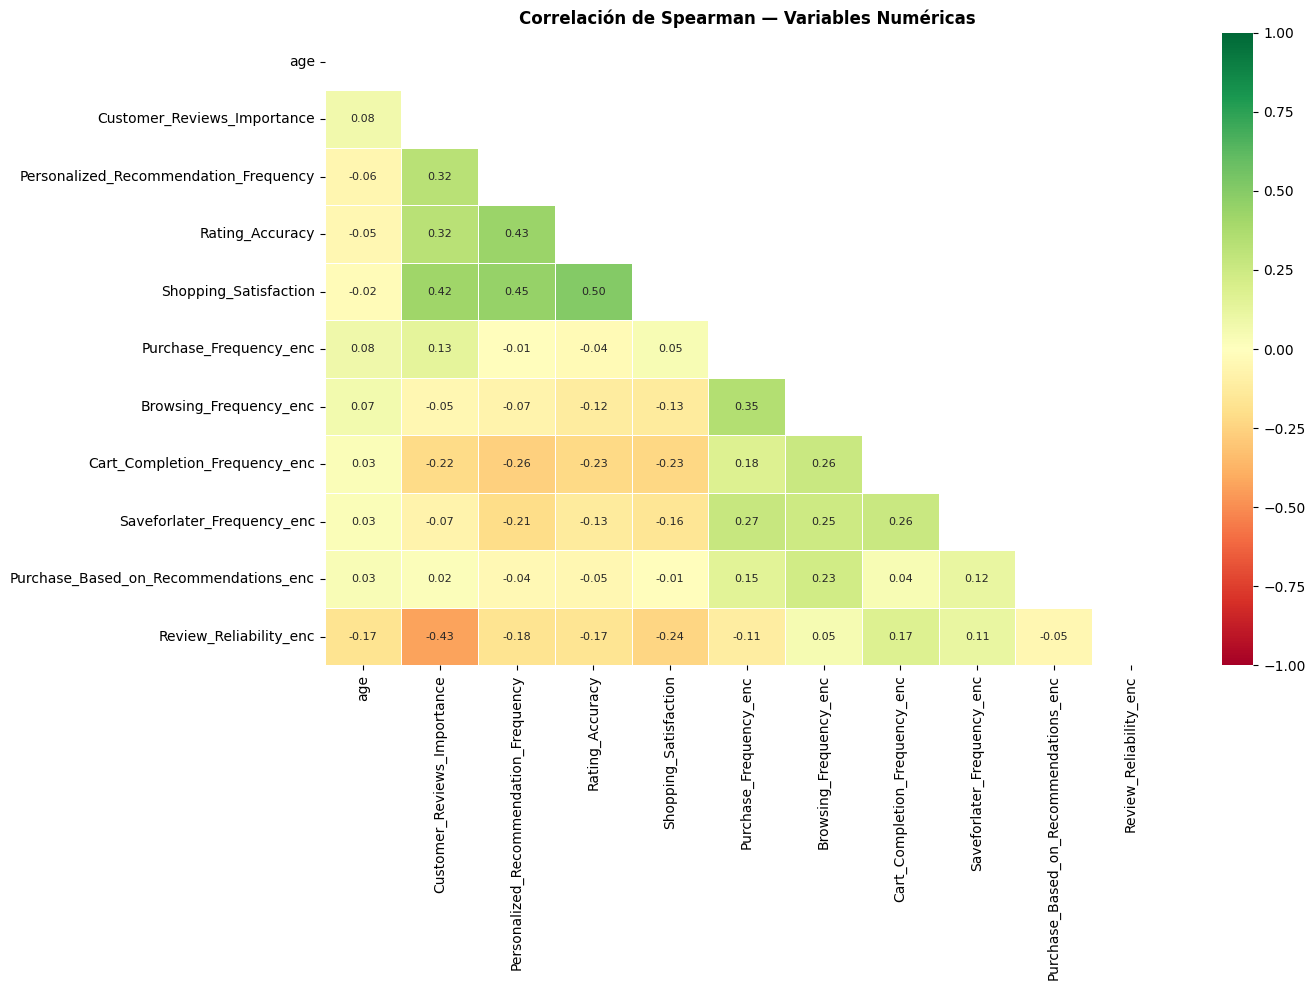

In [40]:
# Correlación de Spearman
corr_matrix = df[columnas_numericas].corr(method="spearman")

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 8}
)
ax.set_title("Correlación de Spearman — Variables Numéricas", fontweight="bold")
plt.tight_layout()
#plt.savefig("src/img/univariante_correlacion.png", bbox_inches="tight", dpi=150)
plt.show()

**Conclusiones — Correlación de Spearman:**

- **Rating_Accuracy ↔ Shopping_Satisfaction** (r=0.50, p<0.001): La correlación más fuerte del dataset. Los usuarios que perciben las valoraciones como más precisas reportan mayor satisfacción general. Esto sugiere que la fiabilidad del sistema de puntuaciones es clave para la experiencia de compra.

- **Shopping_Satisfaction ↔ Customer_Reviews_Importance** (r=0.42, p<0.001): Los usuarios más satisfechos tienden a dar más importancia a las reseñas, posiblemente porque las usan activamente y tienen buenas experiencias.

- **age ↔ Customer_Reviews_Importance** (r=0.08, p=0.059): Tendencia positiva muy débil y no significativa. No hay evidencia estadística de que los usuarios mayores dependan más de las reseñas.

- **age ↔ Shopping_Satisfaction** (r=-0.02, p=0.545): Sin relación. La satisfacción no varía con la edad.

##### Categóricas

In [ ]:
columnas_categoricas = [col for col in df.columns if var_type(col) == "categórica"]

['Gender',
 'Purchase_Frequency',
 'Purchase_Categories',
 'Purchase_Based_on_Recommendations',
 'Browsing_Frequency',
 'Product_Search_Method',
 'Search_Result_Exploration',
 'Add_to_Cart_Browsing',
 'Cart_Completion_Frequency',
 'Cart_Abandonment_Factors',
 'Saveforlater_Frequency',
 'Review_Left',
 'Review_Reliability',
 'Review_Helpfulness',
 'Recommendation_Helpfulness',
 'Service_Appreciation',
 'Improvement_Areas',
 'tramo_edad']

In [ ]:
cols_excluir = set(ordinal_cols.keys()) | {"Timestamp", "Purchase_Categories", "tramo_edad"}
nominales = [c for c in columnas_categoricas if c not in cols_excluir]


['Gender',
 'Product_Search_Method',
 'Search_Result_Exploration',
 'Add_to_Cart_Browsing',
 'Cart_Abandonment_Factors',
 'Review_Left',
 'Review_Helpfulness',
 'Recommendation_Helpfulness',
 'Service_Appreciation',
 'Improvement_Areas',
 'tramo_edad_enc']

In [43]:
# Coger los datos mas relevantes de Service_Appreciation e Improvement_Areas. 
# Tienen respuestas libres y hay muchas respuestas unicas.
top_cats = {
    "Service_Appreciation": [
        "Product recommendations", "Competitive prices",
        "Wide product selection", "User-friendly website/app interface"
    ],
    "Improvement_Areas": [
        "Customer service responsiveness", "Product quality and accuracy",
        "Reducing packaging waste", "Shipping speed and reliability"
    ]
} 

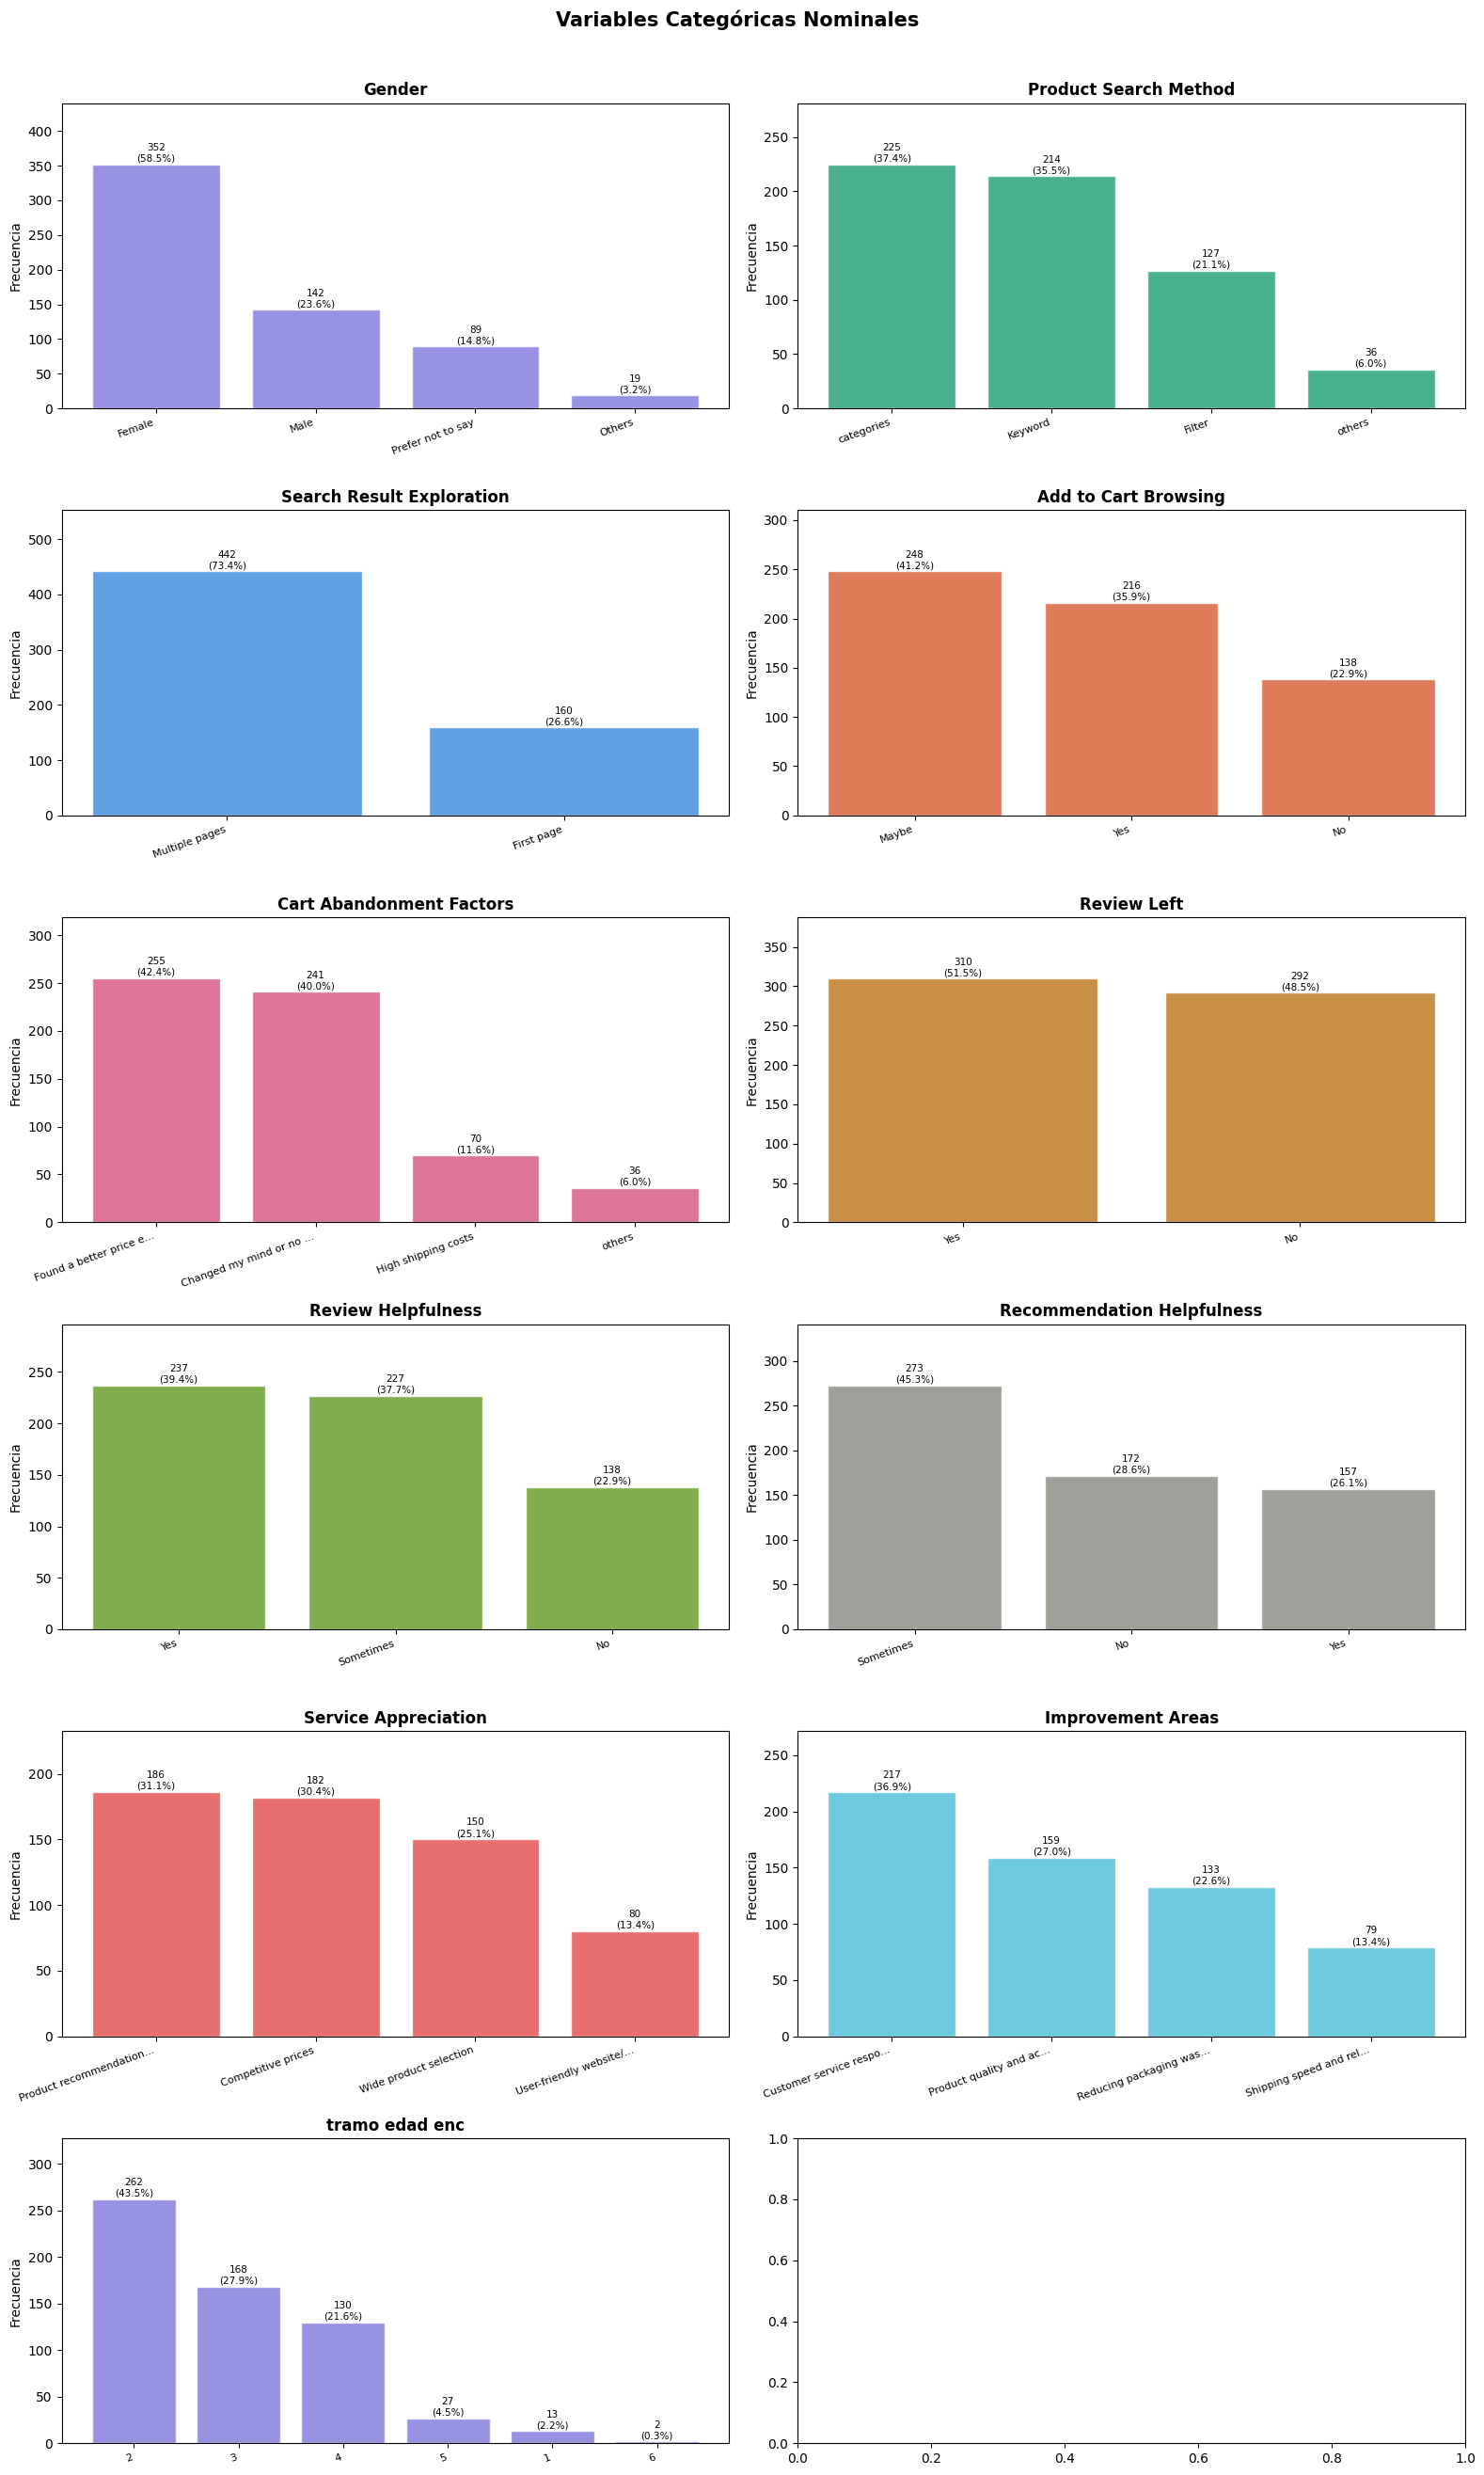

In [44]:
fig, axes = plt.subplots(6, 2, figsize=(16, 26))
axes = axes.flatten()

for i, col in enumerate(nominales):
    ax = axes[i]
    if col in top_cats:
        counts = df[col].value_counts()
        counts = counts[counts.index.isin(top_cats[col])]
    else:
        counts = df[col].value_counts()

    pct = counts / counts.sum() * 100
    bars = ax.bar(range(len(counts)), counts.values,
                  color=COLORES[i % len(COLORES)], alpha=0.8, edgecolor="white")

    for bar, val, p in zip(bars, counts.values, pct.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                f"{val}\n({p:.1f}%)", ha="center", va="bottom", fontsize=7.5)

    labels = [str(x)[:22] + "..." if len(str(x)) > 22 else str(x) for x in counts.index]
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(labels, rotation=20, ha="right", fontsize=8)
    ax.set_title(col.replace("_", " "), fontweight="bold")
    ax.set_ylabel("Frecuencia")
    ax.set_ylim(0, counts.max() * 1.25)

plt.suptitle("Variables Categóricas Nominales", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
#plt.savefig("src/img/univariante_nominales.png", bbox_inches="tight", dpi=150)
plt.show()

**Conclusiones — Variables Categóricas Nominales:**

- **Gender**: Muestra predominantemente femenina (58.5%). El 14.8% prefiere no indicar su género, lo que puede sesgar los análisis por género.

- **Cart_Abandonment_Factors**: El 42.4% abandona por encontrar mejor precio en otro sitio y el 40% por cambio de opinión. El precio competitivo es el principal reto para retener al comprador, más que el coste de envío (11.6%).

- **Review_Left**: La comunidad está dividida casi al 50% — el 51.5% deja reseñas y el 48.5% no. Esto indica una base activa pero con mucho potencial de activación.

- **Review_Helpfulness**: Solo el 39.4% considera las reseñas siempre útiles. El 22.9% no las encuentra útiles, lo que sugiere un problema de calidad o relevancia de las reseñas.

- **Recommendation_Helpfulness**: Las recomendaciones personalizadas generan escepticismo — solo el 26.1% las considera útiles y el 28.6% directamente no las encuentra útiles.

- **Service_Appreciation**: Los usuarios valoran principalmente las recomendaciones de producto (30.7%) y los precios competitivos (30.2%), ambos casi empatados.

- **Improvement_Areas**: La atención al cliente es la principal área de mejora demandada (36.1%), seguida de la calidad del producto (26.4%).

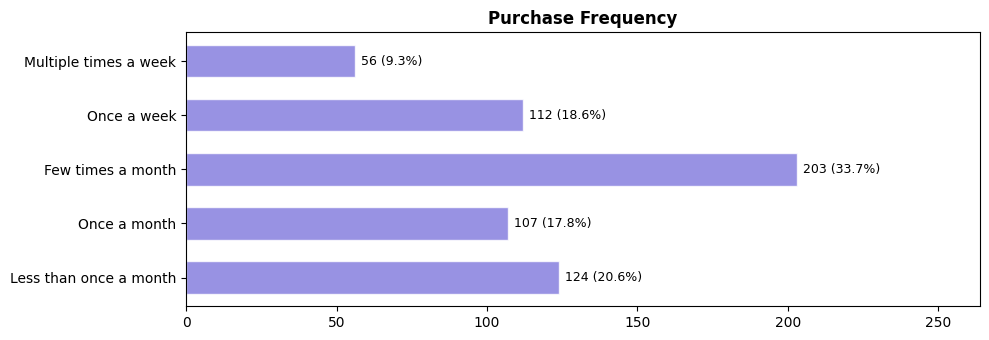

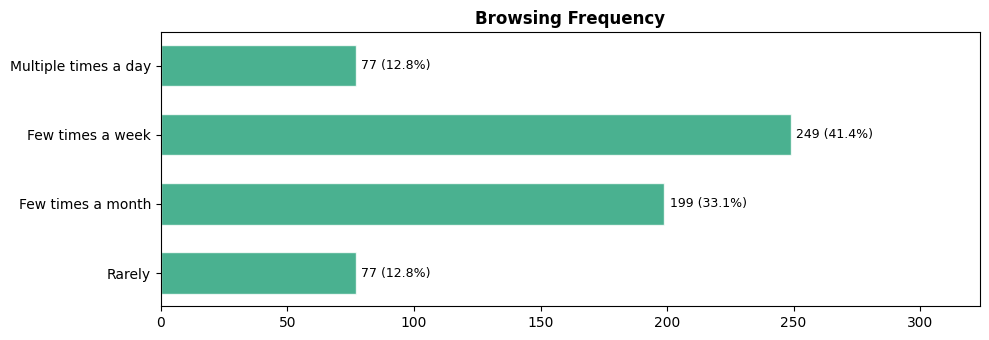

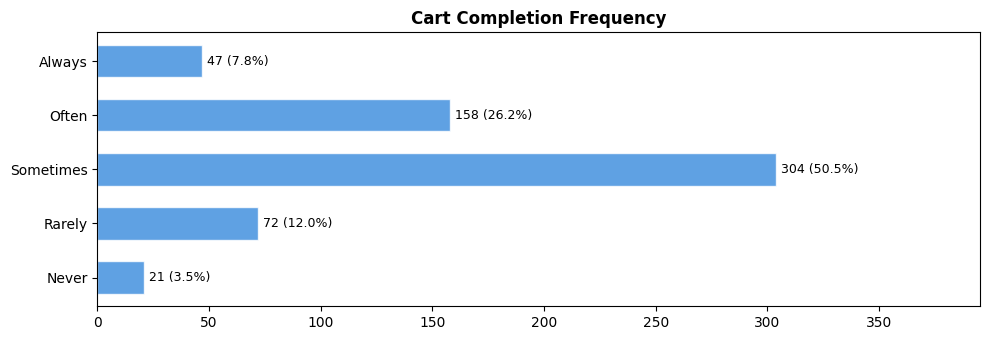

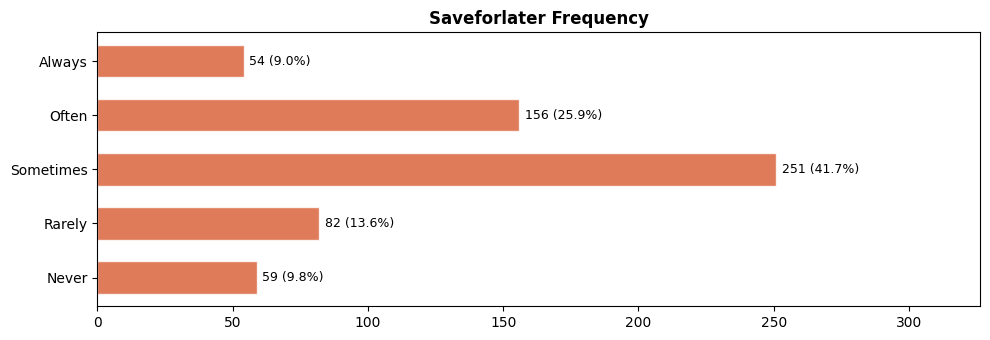

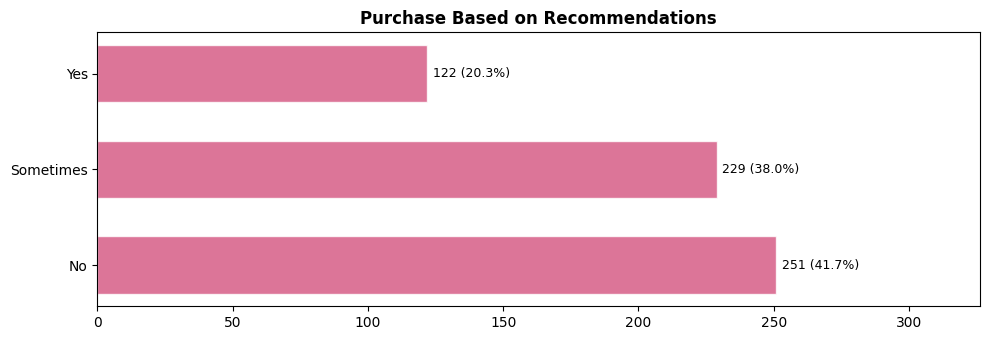

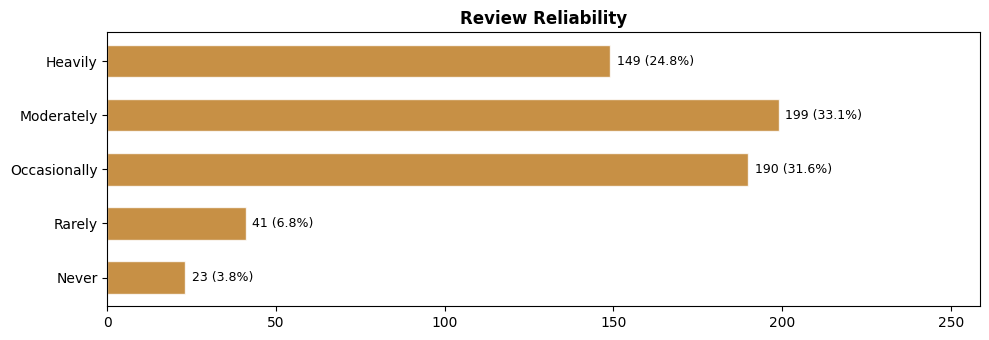

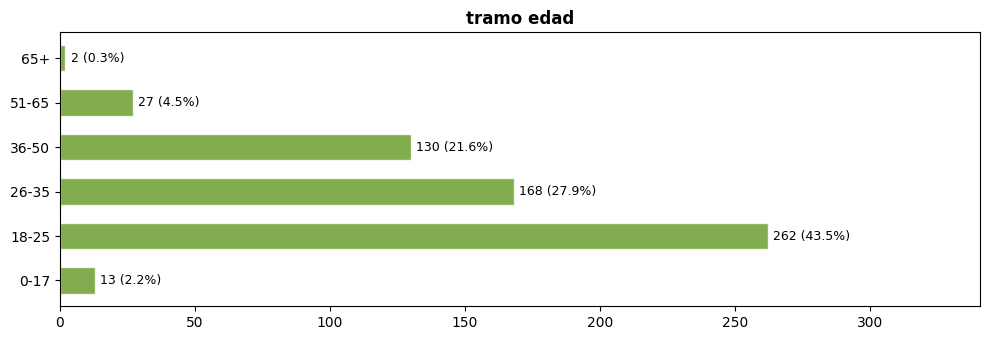

In [45]:
for i, col in enumerate(ordinal_cols.keys()):
    fig, ax = plt.subplots(figsize=(10, 3.5))
    orden = ordinal_cols[col]
    counts = df[col].value_counts().reindex(orden, fill_value=0)
    pct = counts / counts.sum() * 100

    bars = ax.barh(orden, counts.values, color=COLORES[i % len(COLORES)],
                   alpha=0.8, edgecolor="white", height=0.6)

    for bar, val, p in zip(bars, counts.values, pct.values):
        ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height() / 2,
                f"{val} ({p:.1f}%)", va="center", fontsize=9)

    ax.set_title(col.replace("_", " "), fontweight="bold")
    ax.set_xlim(0, max(counts.max() * 1.3, 10))

    plt.tight_layout()
    #plt.savefig(f"src/img/univariante_ordinales_{col}.png", bbox_inches="tight", dpi=150)
    plt.show()

**Conclusiones — Variables Ordinales:**

- **Purchase_Frequency**: El 33.7% compra pocas veces al mes — el segmento más grande. Solo el 9.3% compra varias veces a la semana, lo que indica que los compradores de alta frecuencia son una minoría valiosa.

- **Browsing_Frequency**: El 41.4% navega pocas veces a la semana. Hay más usuarios que navegan con frecuencia de la que compran, lo que confirma la existencia de un segmento de navegadores no compradores.

- **Cart_Completion_Frequency**: El 50.5% completa la compra solo a veces. Solo el 7.8% siempre completa la compra, lo que indica altas tasas de abandono de carrito como patrón estructural.

- **Saveforlater_Frequency**: El 41.7% guarda para más tarde a veces. Es una función moderadamente usada, lo que sugiere indecisión o comparación de precios.

- **Review_Reliability**: El 33.1% confía moderadamente en las reseñas y el 31.6% solo ocasionalmente. Solo el 24.8% confía mucho en ellas, lo que refleja escepticismo generalizado.

- **tramo_edad**: El 43.5% tiene entre 18 y 25 años, lo que convierte a los jóvenes adultos en el segmento dominante. Los mayores de 50 años representan menos del 5% de la muestra.

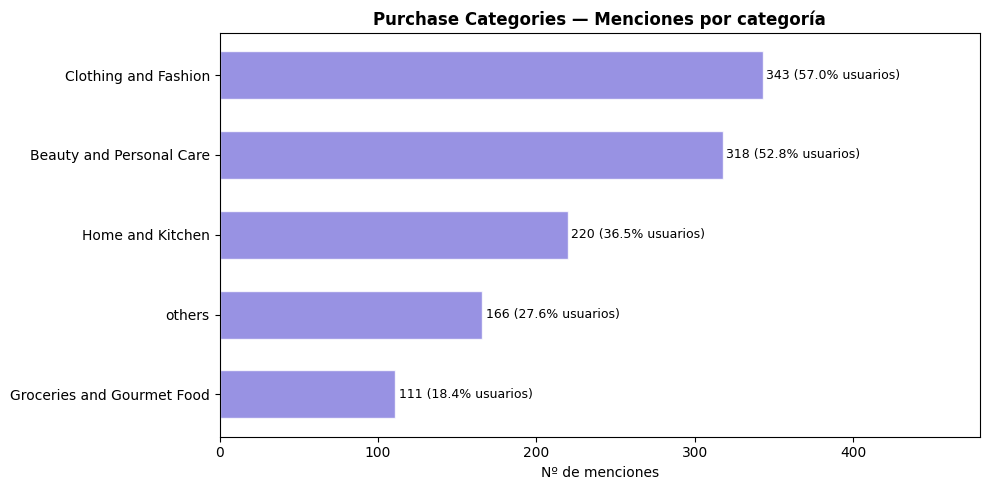

In [46]:
cat_exploded = df["Purchase_Categories"].str.split(";").explode().str.strip()
cat_counts = cat_exploded.value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(cat_counts.index, cat_counts.values,
               color=COLORES[0], alpha=0.8, edgecolor="white", height=0.6)

for bar, val in zip(bars, cat_counts.values):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height() / 2,
            f"{val} ({val/602*100:.1f}% usuarios)", va="center", fontsize=9)

ax.set_title("Purchase Categories — Menciones por categoría", fontweight="bold")
ax.set_xlabel("Nº de menciones")
ax.set_xlim(0, cat_counts.max() * 1.4)
ax.invert_yaxis()
plt.tight_layout()
#plt.savefig("src/img/univariante_categories.png", bbox_inches="tight", dpi=150)
plt.show()

In [47]:
# Nº medio de categorías por usuario
n_cats = df["Purchase_Categories"].str.split(";").apply(len)
print(f"Media de categorías por usuario: {n_cats.mean():.2f}")
print(f"Máximo: {n_cats.max()} | Mínimo: {n_cats.min()}")
print(cat_counts.sort_index())

Media de categorías por usuario: 1.92
Máximo: 5 | Mínimo: 1
Purchase_Categories
Beauty and Personal Care      318
Clothing and Fashion          343
Groceries and Gourmet Food    111
Home and Kitchen              220
others                        166
Name: count, dtype: int64


**Conclusiones — Purchase Categories:**

- **Clothing and Fashion** (29.6%) y **Beauty and Personal Care** (27.5%) son las categorías más compradas, reflejando el perfil mayoritariamente femenino y joven de la muestra.

- **Home and Kitchen** (19%) ocupa el tercer puesto, lo que indica un segmento de compradores del hogar relevante.

- **Groceries and Gourmet Food** solo aparece en el 9.6% de las menciones, lo que sugiere que Amazon no es el canal principal para alimentación en esta muestra.

- Los usuarios compran de media en más de una categoría, lo que indica comportamiento de compra diversificado.

#### Analysis bivariante

##### *Numérica vs Numérica*

In [48]:
cols_num_plot = ["age", "Customer_Reviews_Importance", "Rating_Accuracy", "Shopping_Satisfaction"]
pares = list(combinations(cols_num_plot, 2))

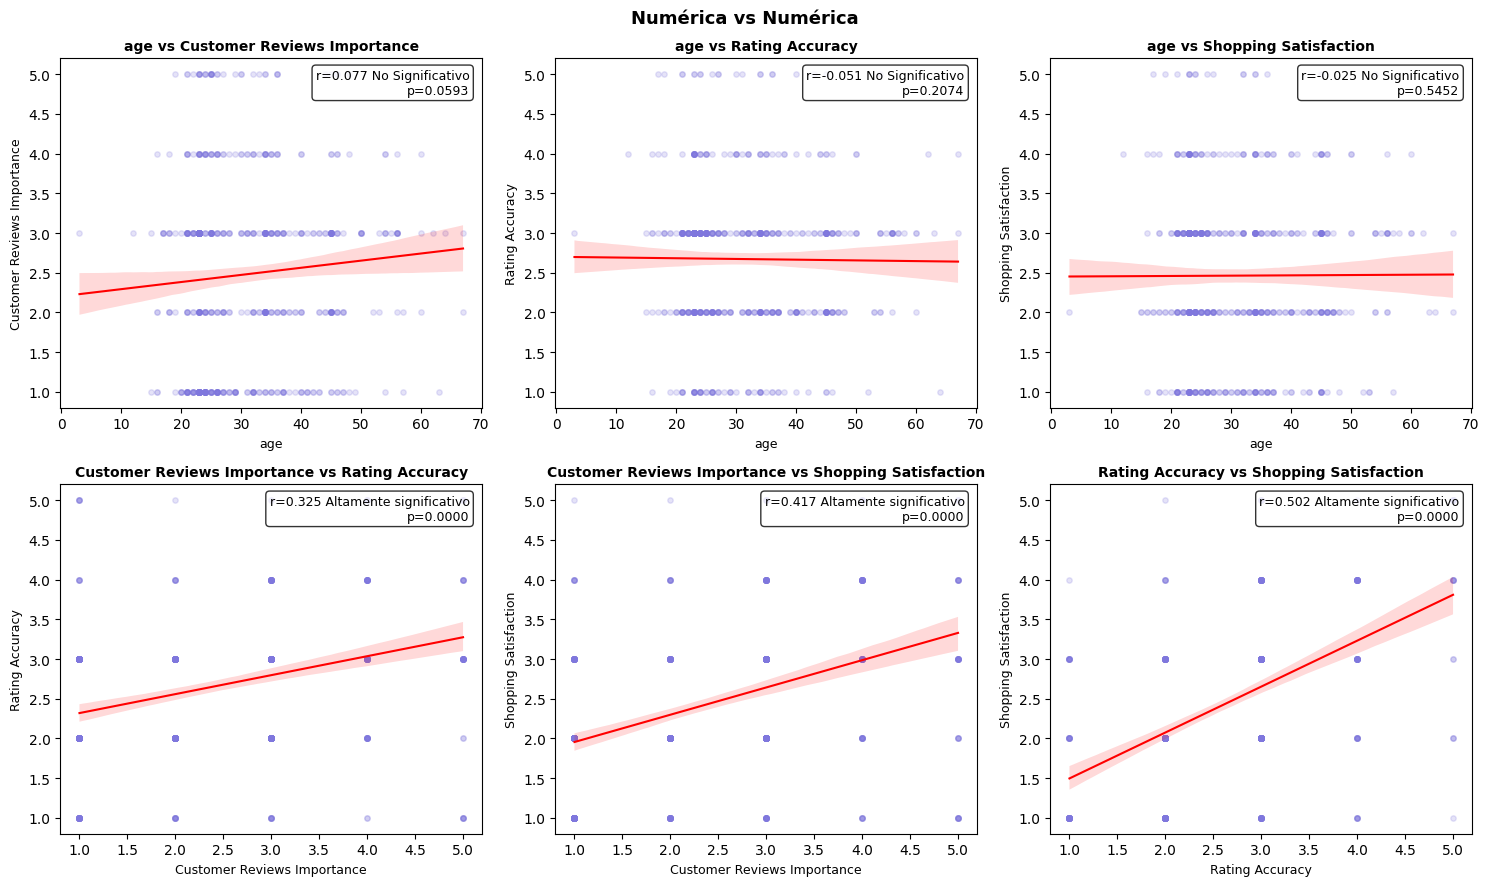

In [49]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, (x, y) in enumerate(pares):
    ax = axes[i]
    r, p = spearmanr(df[x], df[y])
    sns.regplot(data=df, x=x, y=y, ax=ax,
                scatter_kws={"alpha":0.2,"s":15}, line_kws={"color":"red","lw":1.5})
    ax.set_title(f"{x.replace("_"," ")} vs {y.replace("_"," ")}", fontsize=10, fontweight="bold")
    ax.set_xlabel(x.replace("_"," "), fontsize=9)
    ax.set_ylabel(y.replace("_"," "), fontsize=9)
    ax.annotate(f"r={r:.3f} {significancia(p)}\np={p:.4f}", xy=(0.97,0.97),
                xycoords="axes fraction", ha="right", va="top", fontsize=9,
                bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

for j in range(len(pares), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numérica vs Numérica", fontsize=13, fontweight="bold")
plt.tight_layout()
#plt.savefig("src/img/biv_num_num.png", bbox_inches="tight", dpi=150)
plt.show()

**Conclusiones — Scatter Numérica vs Numérica:**

- **Rating_Accuracy ↔ Shopping_Satisfaction** (r=0.50, ***): La relación más fuerte. Cuando los usuarios perciben las valoraciones como más precisas, su satisfacción aumenta significativamente. Mejorar el sistema de ratings tendría impacto directo en la satisfacción.

- **Shopping_Satisfaction ↔ Customer_Reviews_Importance** (r=0.42, ***): Los usuarios satisfechos valoran más las reseñas, lo que puede indicar que las reseñas contribuyen a tomar mejores decisiones de compra.

- **Rating_Accuracy ↔ Customer_Reviews_Importance** (r=0.30, ***): Correlación moderada. Quien más usa reseñas también presta más atención a la precisión de las valoraciones — son perfiles coherentes.

- **age**: No muestra correlación significativa con ninguna de las otras variables numéricas, lo que sugiere que la edad no determina por sí sola la experiencia o el comportamiento en Amazon.

##### *Numérica vs Categórica — Boxplots*

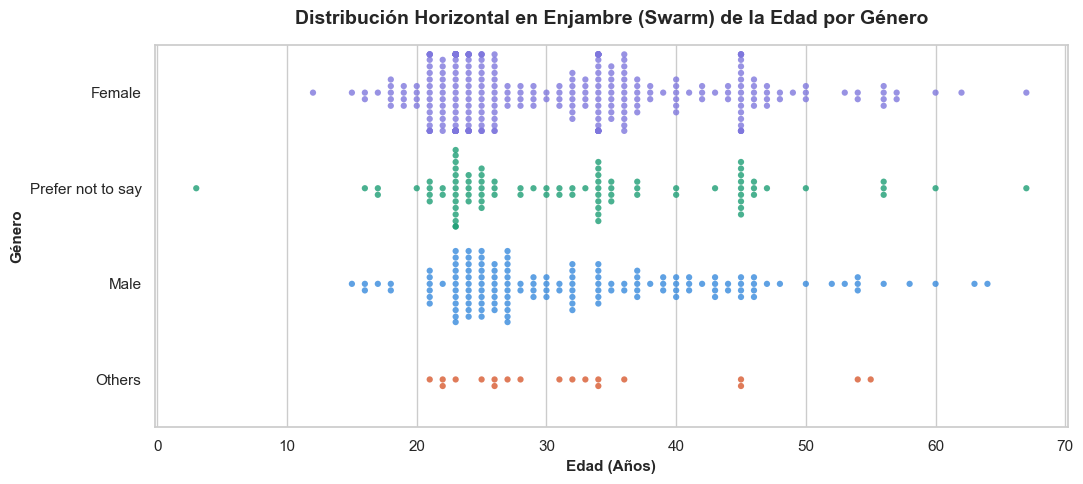

In [50]:
plt.figure(figsize=(11, 5))
sns.set_theme(style="whitegrid")

sns.swarmplot(
    x='age',              
    y='Gender',           
    data=df, 
    palette=COLORES,      
    size=4.5,             
    alpha=0.8            
)

plt.title("Distribución Horizontal en Enjambre (Swarm) de la Edad por Género", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Edad (Años)", fontsize=11, fontweight='bold')
plt.ylabel("Género", fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

**Conclusión - Distribución de Edad por Género:** 
 - **Concentración Juvenil:** Existe una densidad crítica de usuarios concentrada entre los 18 y 35 años en todos los géneros, lo que indica un perfil de encuestado marcadamente joven.
 - **Simetría Demográfica:** Las distribuciones de edad para los segmentos masculino y femenino son sumamente homogéneas, compartiendo los mismos rangos de concentración y dispersión.
 - **Representación Senior Limitada:** Los usuarios mayores de 50 años actúan como "outliers" demográficos (puntos muy dispersos), siendo el grupo femenino el que muestra una presencia sutilmente más continua en estas edades avanzadas dentro de la muestra.

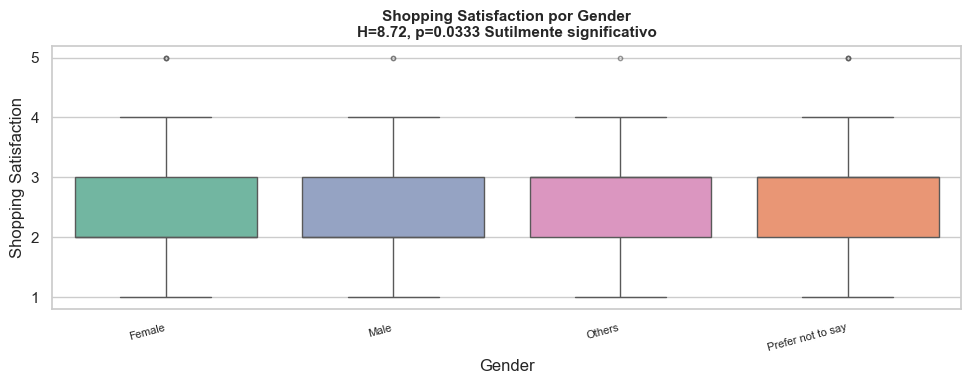

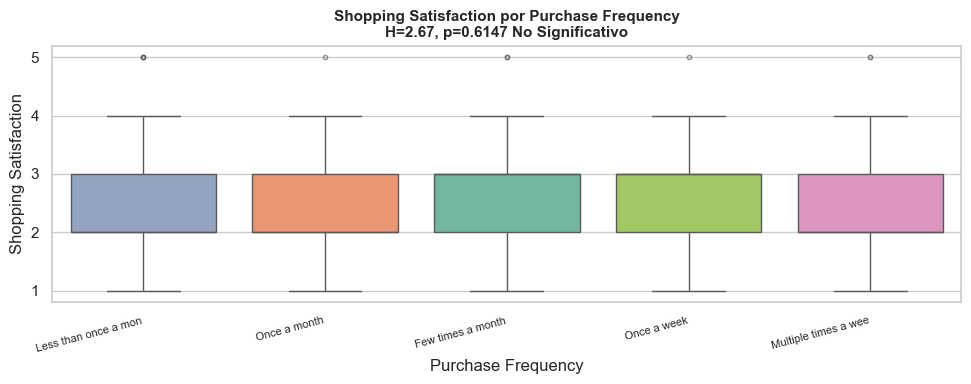

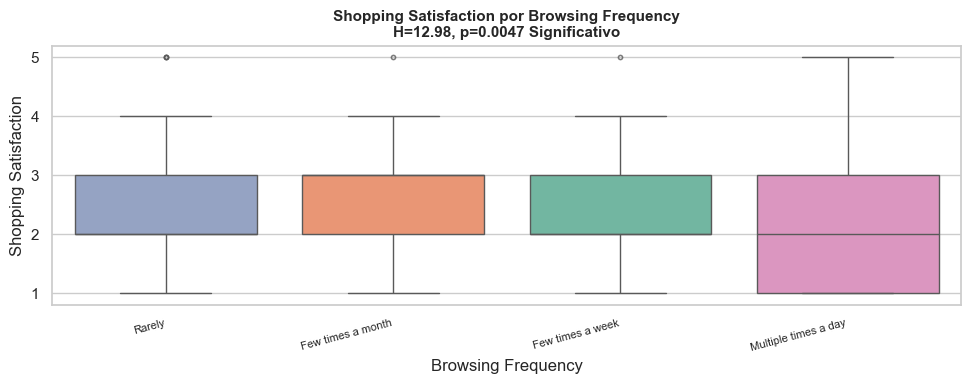

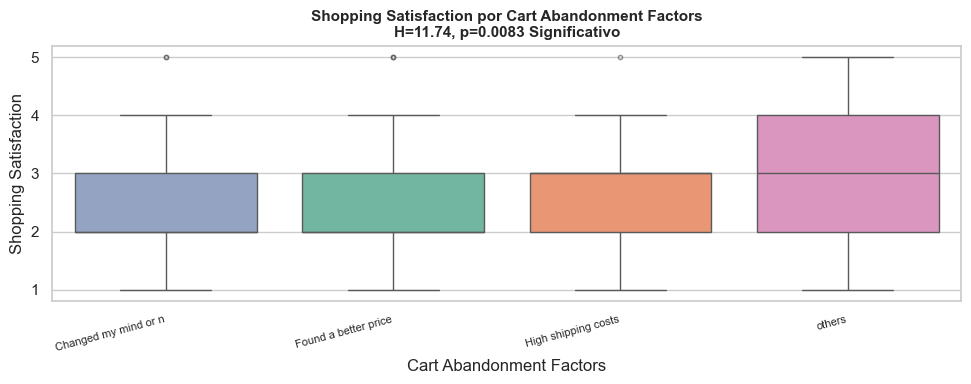

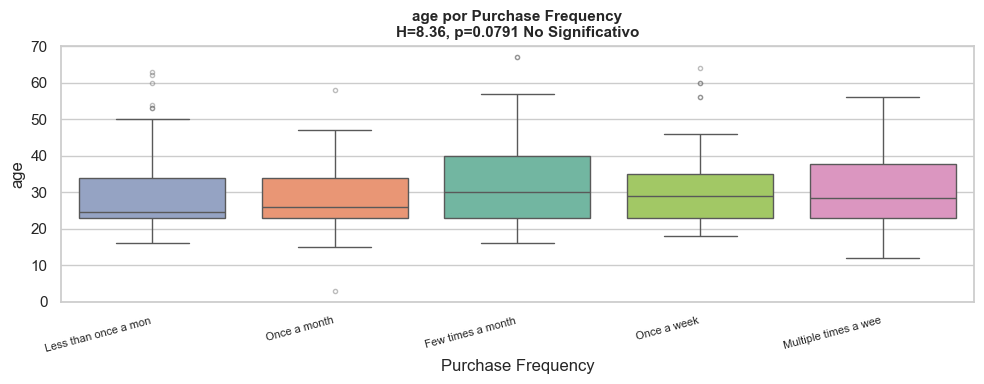

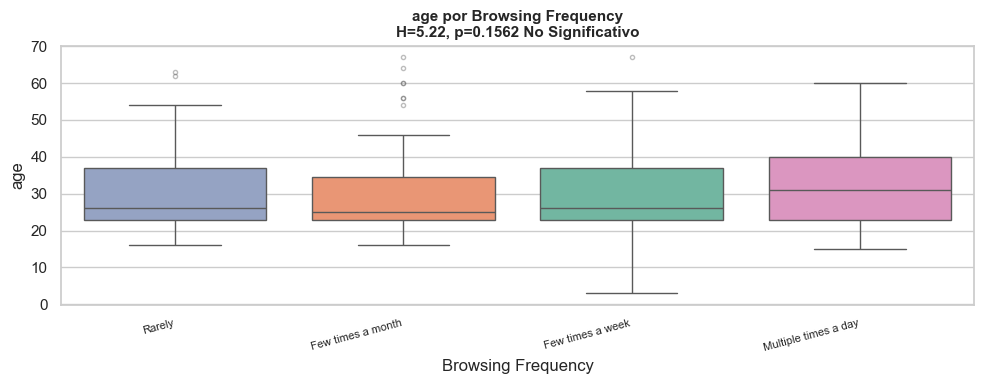

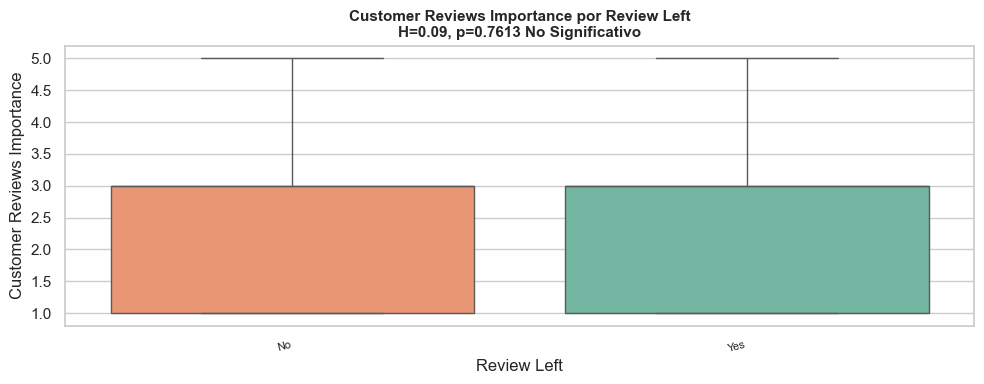

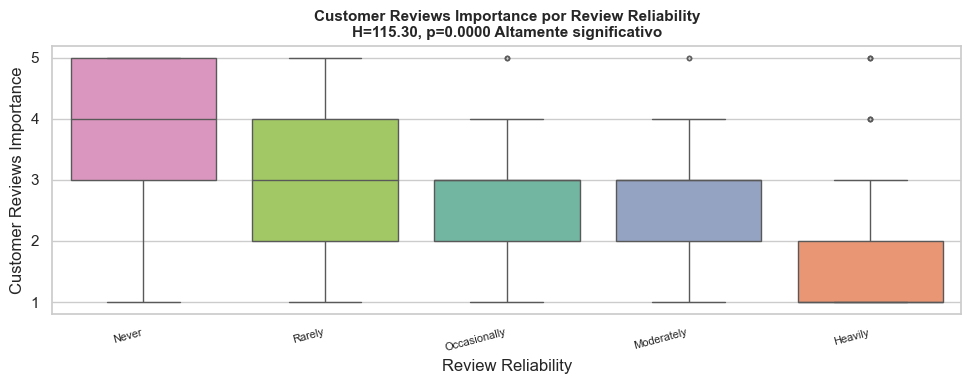

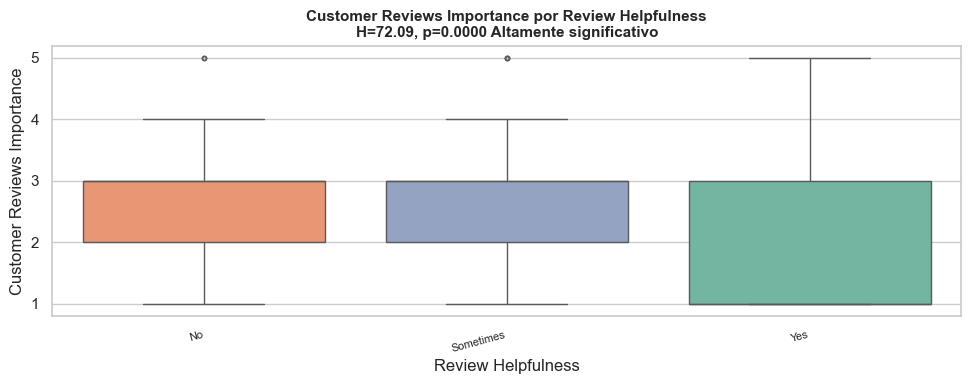

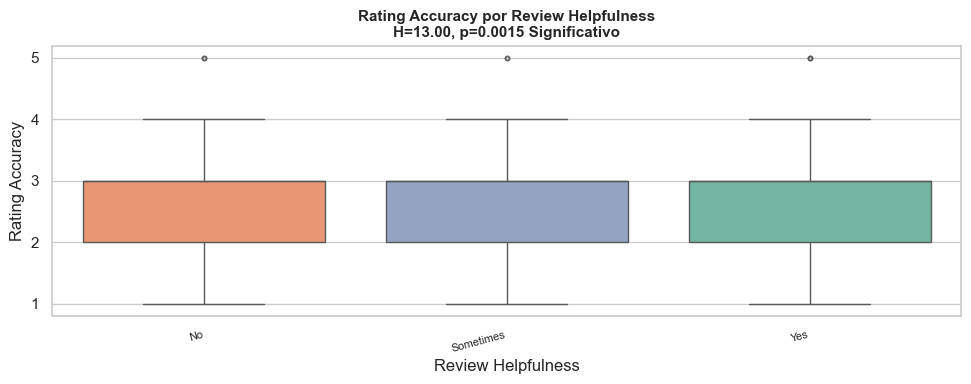

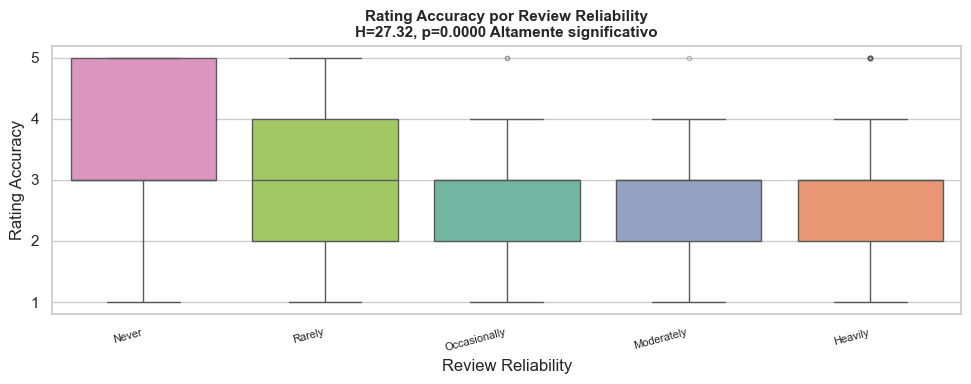

In [51]:
pares_nc = [
    ("Shopping_Satisfaction", "Gender"),
    ("Shopping_Satisfaction", "Purchase_Frequency"),
    ("Shopping_Satisfaction", "Browsing_Frequency"),
    ("Shopping_Satisfaction", "Cart_Abandonment_Factors"),
    ("age",                   "Purchase_Frequency"),
    ("age",                   "Browsing_Frequency"),
    ("Customer_Reviews_Importance", "Review_Left"),
    ("Customer_Reviews_Importance", "Review_Reliability"),
    ("Customer_Reviews_Importance", "Review_Helpfulness"),
    ("Rating_Accuracy",       "Review_Helpfulness"),
    ("Rating_Accuracy",       "Review_Reliability"),
]


for num, cat in pares_nc:
    orden = ordinal_cols.get(cat, sorted(df[cat].dropna().unique()))
    grupos = [df[df[cat]==g][num].dropna() for g in orden if len(df[df[cat]==g][num].dropna()) > 0]
    labels = [o for o in orden if len(df[df[cat]==o][num].dropna()) > 0]

    stat, p = kruskal(*grupos) if len(grupos) >= 2 else (0, 1)

    fig, ax = plt.subplots(figsize=(10, 4))
    sns.boxplot(data=df, x=cat, y=num, order=labels, palette="Set2", ax=ax,
            hue=cat, legend=False, flierprops=dict(marker="o", markersize=3, alpha=0.4))
    ax.set_title(f"{num.replace("_"," ")} por {cat.replace("_"," ")}\nH={stat:.2f}, p={p:.4f} {significancia(p)}",
                 fontweight="bold", fontsize=11)
    ax.set_xlabel(cat.replace("_"," "))
    ax.set_ylabel(num.replace("_"," "))
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels([l[:20] for l in labels], rotation=15, ha="right", fontsize=8)
    plt.tight_layout()
    #plt.savefig(f"src/img/biv_{num}_vs_{cat}.png", bbox_inches="tight", dpi=150)
    plt.show()

**Conclusiones — Numérica vs Categórica:**

- **Satisfacción por Género** (H=8.72, p=0.033, *): Diferencias significativas. El grupo 'Others' tiene la mayor satisfacción media (2.84) y los hombres la menor (2.30). Las mujeres se sitúan en la media general (2.46).

- **Satisfacción por Purchase_Frequency** (H=2.67, p=0.615, ns): Sin diferencias significativas. La frecuencia de compra no determina la satisfacción — compradores habituales y esporádicos reportan niveles similares.

- **Satisfacción por Browsing_Frequency** (H=12.98, p=0.005, **): Diferencias significativas. Los usuarios que navegan raramente tienen mayor satisfacción media (2.71) que los que navegan varias veces al día (2.12). Navegar mucho sin comprar puede generar frustración.

- **Edad por Purchase_Frequency** (H=8.36, p=0.079, ns): Tendencia leve sin significación estadística. No hay evidencia clara de que la edad determine la frecuencia de compra.

- **Customer_Reviews_Importance por Review_Left** (H=0.09, p=0.761, ns): Sin diferencias. La importancia que se da a las reseñas no predice si el usuario las deja o no.

- **Customer_Reviews_Importance por Review_Reliability** (H=115.30, p<0.001, ***): Relación muy significativa e inversa. Los que confían 'Heavily' en reseñas les dan paradójicamente menos importancia en su decisión (media 1.76), mientras que los que 'Never' confían les dan más importancia (media 3.65). Esto sugiere que confiar en reseñas y darles importancia son conceptos distintos.

##### *Categórica vs Categórica — Barras apiladas + Chi²*

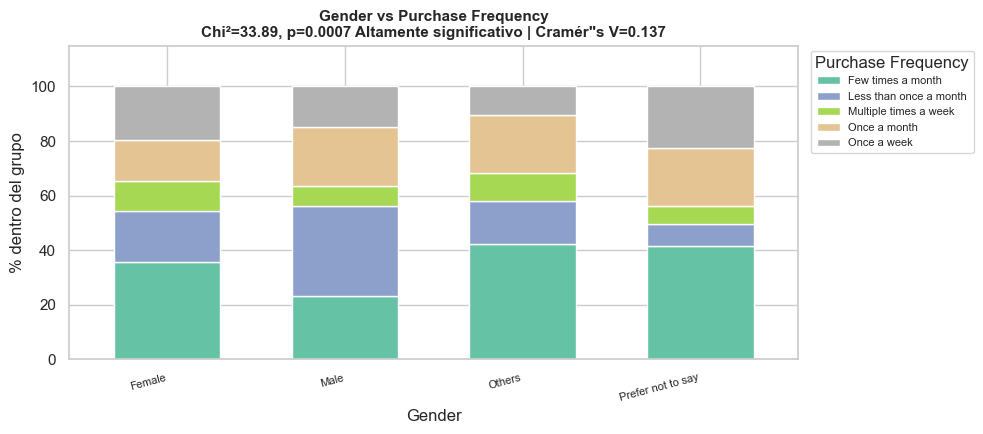

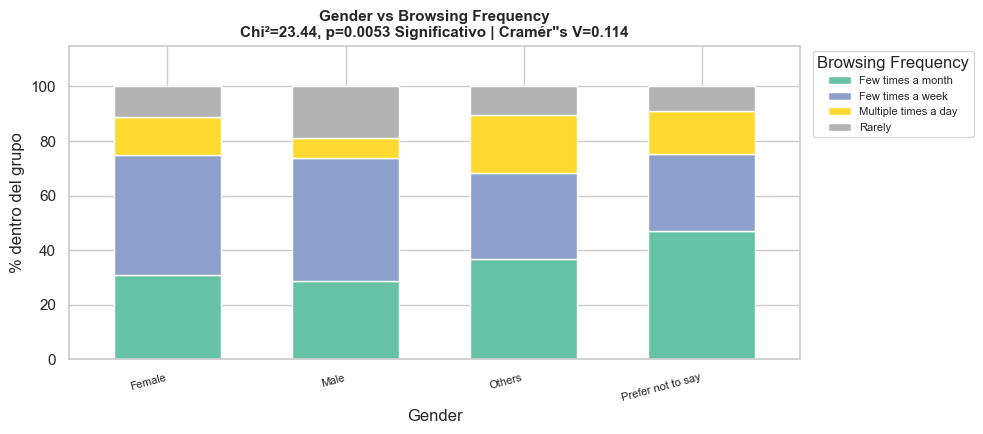

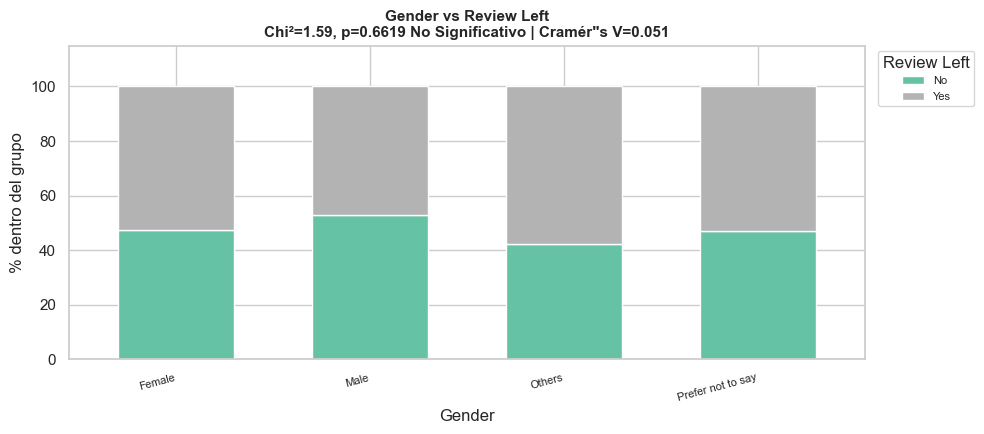

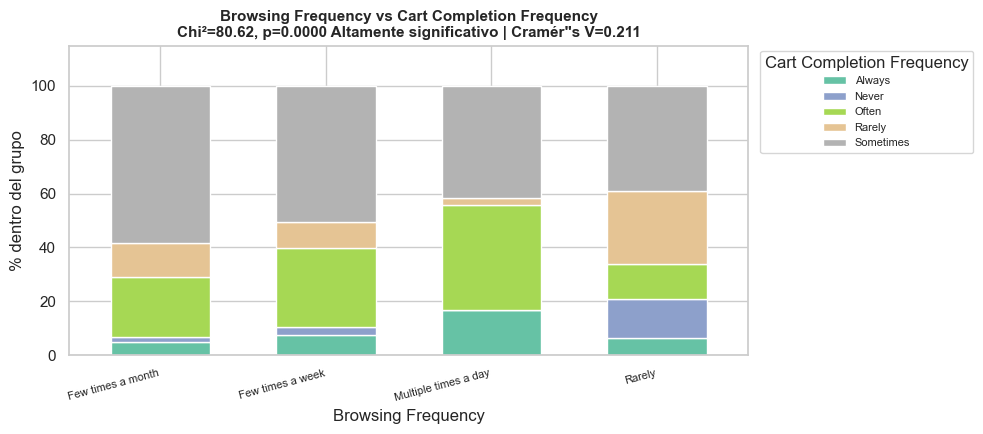

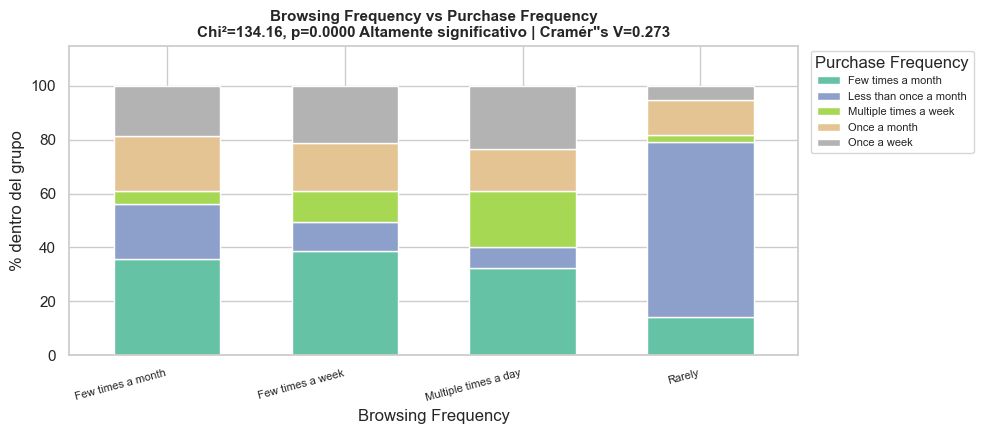

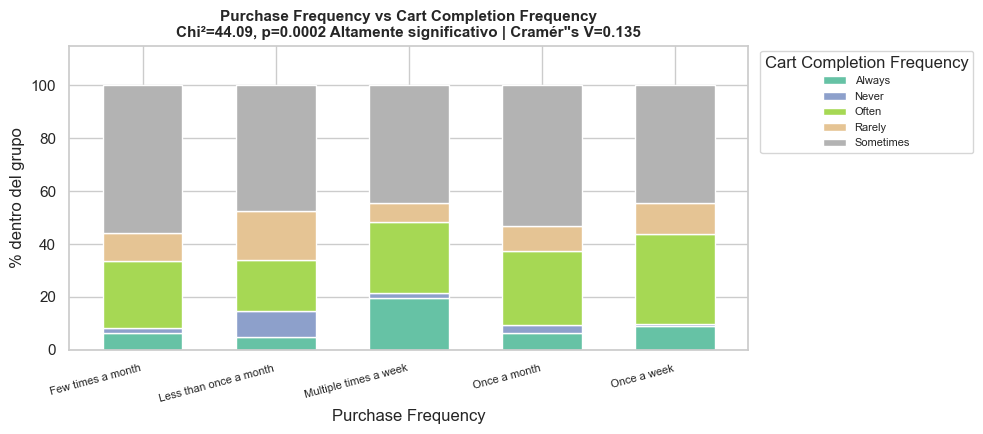

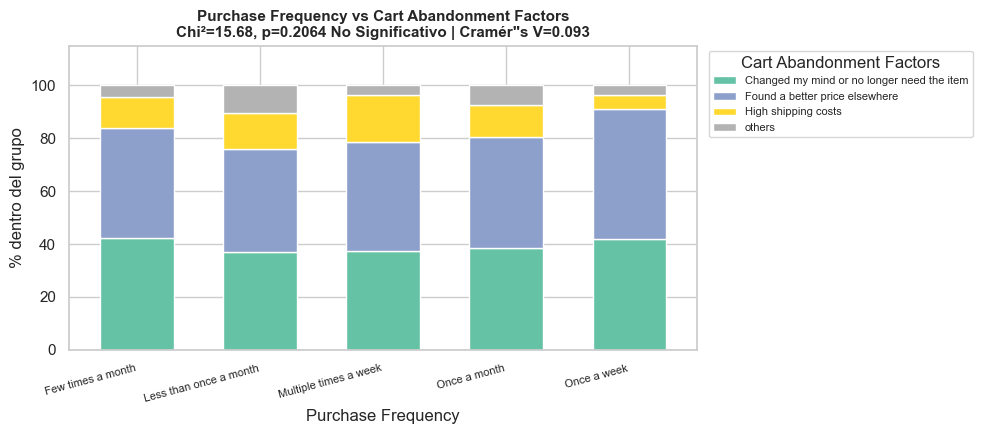

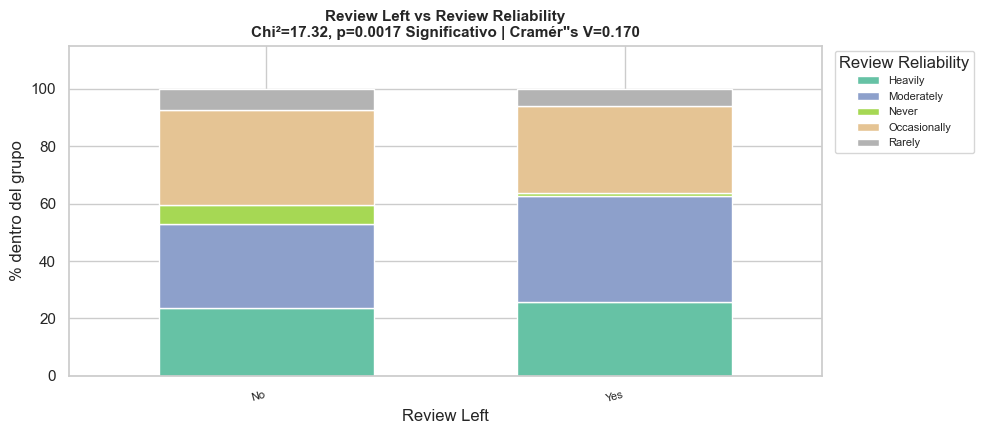

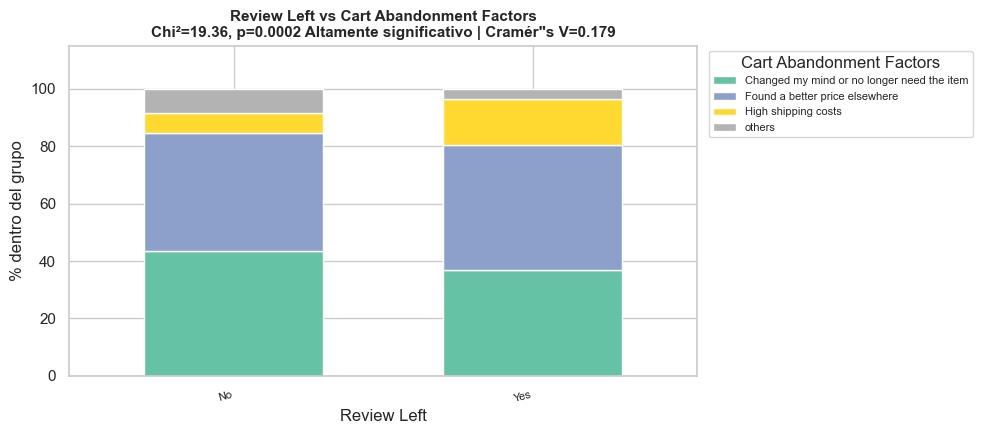

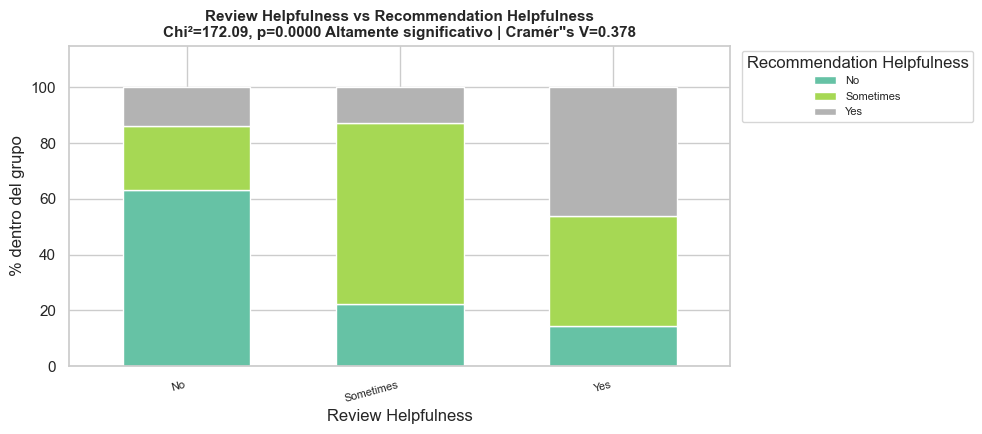

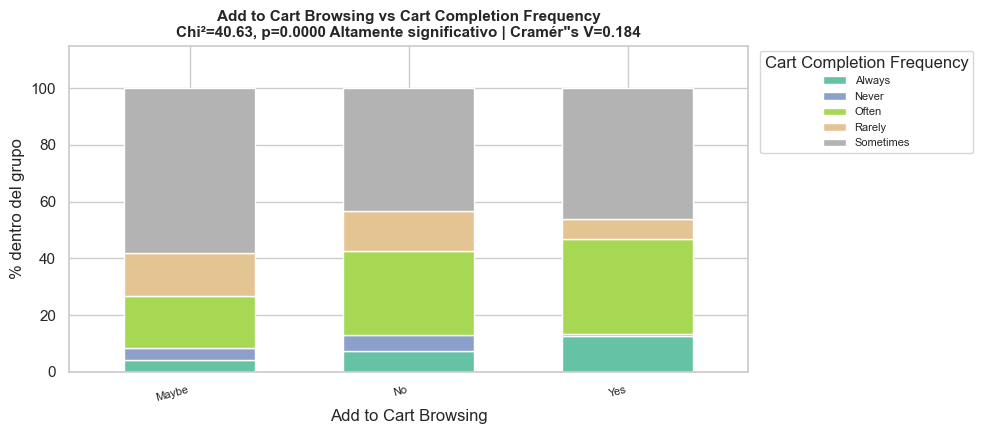

In [52]:
pares_cc = [
    ("Gender",              "Purchase_Frequency"),
    ("Gender",              "Browsing_Frequency"),
    ("Gender",              "Review_Left"),
    ("Browsing_Frequency",  "Cart_Completion_Frequency"),
    ("Browsing_Frequency",  "Purchase_Frequency"),
    ("Purchase_Frequency",  "Cart_Completion_Frequency"),
    ("Purchase_Frequency",  "Cart_Abandonment_Factors"),
    ("Review_Left",         "Review_Reliability"),
    ("Review_Left",         "Cart_Abandonment_Factors"),
    ("Review_Helpfulness",  "Recommendation_Helpfulness"),
    ("Add_to_Cart_Browsing","Cart_Completion_Frequency"),
]

for cat1, cat2 in pares_cc:
    ct = pd.crosstab(df[cat1], df[cat2])
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    chi2, p, _, _ = chi2_contingency(ct)
    v = np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1)))

    fig, ax = plt.subplots(figsize=(10, 4.5))
    ct_pct.plot(kind="bar", stacked=True, ax=ax, colormap="Set2", edgecolor="white", width=0.6)
    ax.set_title(f"{cat1.replace("_"," ")} vs {cat2.replace("_"," ")}\nChi²={chi2:.2f}, p={p:.4f} {significancia(p)} | Cramér\"s V={v:.3f}",
                 fontweight="bold", fontsize=11)
    ax.set_xlabel(cat1.replace("_"," "))
    ax.set_ylabel("% dentro del grupo")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right", fontsize=8)
    ax.legend(title=cat2.replace("_"," "), bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
    ax.set_ylim(0, 115)
    plt.tight_layout()
    #plt.savefig(f"src/img/biv_{cat1}_vs_{cat2}.png", bbox_inches="tight", dpi=150)
    plt.show()

**Conclusiones — Categórica vs Categórica:**

- **Browsing_Frequency ↔ Purchase_Frequency** (Chi²=134.16, p<0.001, V=0.273): Asociación significativa y moderada. Los usuarios que navegan más frecuentemente también compran con mayor frecuencia, aunque la relación no es perfecta — existe un segmento que navega sin comprar.

- **Browsing_Frequency ↔ Cart_Completion_Frequency** (Chi²=80.62, p<0.001, V=0.211): Asociación significativa. Los que navegan varias veces al día tienen una tasa de completitud de carrito notablemente superior a los que navegan raramente. La navegación frecuente está asociada a mayor intención de compra.

- **Add_to_Cart_Browsing ↔ Cart_Completion_Frequency** (Chi²=40.63, p<0.001, V=0.184): Los usuarios que añaden productos al carrito mientras navegan tienden a completar más compras. Añadir al carrito es un indicador de intención de compra real.

- **Review_Left ↔ Review_Reliability** (Chi²=17.32, p=0.002, V=0.170): Los usuarios que dejan reseñas confían más en ellas. Hay coherencia entre el comportamiento de escribir reseñas y la confianza en el sistema.

- **Review_Helpfulness ↔ Recommendation_Helpfulness** (asociación significativa): Los usuarios que encuentran útiles las reseñas también tienden a encontrar útiles las recomendaciones personalizadas — perfil de usuario receptivo a la información social.

##### *Resumen estadístico de todos los pares*

In [ ]:
resultados = []

for x, y in combinations(columnas_numericas, 2):
    r, p = spearmanr(df[x], df[y])
    resultados.append({"var1":x,"var2":y,"test":"Spearman","estadístico":round(r,4),"p_valor":round(p,4),"significancia":significancia(p)})

for num, cat in pares_nc:
    grupos = [df[df[cat]==g][num].dropna() for g in df[cat].dropna().unique() if len(df[df[cat]==g][num].dropna()) > 0]
    if len(grupos) >= 2:
        stat, p = kruskal(*grupos)
        resultados.append({"var1":num,"var2":cat,"test":"Kruskal-Wallis","estadístico":round(stat,4),"p_valor":round(p,4),"significancia":significancia(p)})

for cat1, cat2 in pares_cc:
    ct = pd.crosstab(df[cat1], df[cat2])
    chi2, p, _, _ = chi2_contingency(ct)
    v = np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1)))
    resultados.append({"var1":cat1,"var2":cat2,"test":"Chi²","estadístico":round(chi2,4),"p_valor":round(p,4),"significancia":significancia(p)})

df_res = pd.DataFrame(resultados).fillna("-").sort_values("p_valor")
df_res

,var1,var2,test,estadístico,p_valor,significancia
12,Customer_Reviews_Importance,Shopping_Satisfaction,Spearman,0.4169,0.0000,Altamente significativo
11,Customer_Reviews_Importance,Rating_Accuracy,Spearman,0.3248,0.0000,Altamente significativo
10,Customer_Reviews_Importance,Personalized_Recommendation_Frequency,Spearman,0.3215,0.0000,Altamente significativo
15,Customer_Reviews_Importance,Cart_Completion_Frequency_enc,Spearman,-0.2155,0.0000,Altamente significativo
9,age,Review_Reliability_enc,Spearman,-0.1720,0.0000,Altamente significativo
...,...,...,...,...,...,...
68,Gender,Review_Left,Chi²,1.5890,0.6619,No Significativo
17,Customer_Reviews_Importance,Purchase_Based_on_Recommendations_enc,Spearman,0.0161,0.6925,No Significativo
61,Customer_Reviews_Importance,Review_Left,Kruskal-Wallis,0.0923,0.7613,No Significativo
38,Shopping_Satisfaction,Purchase_Based_on_Recommendations_enc,Spearman,-0.0107,0.7925,No Significativo


**Conclusiones — Resumen estadístico:**

- Las relaciones más fuertes y significativas del dataset son **Browsing_Frequency ↔ Purchase_Frequency** (V=0.273) y **Rating_Accuracy ↔ Shopping_Satisfaction** (r=0.50), ambas con p<0.001.

- La mayoría de los pares cat-cat muestran asociaciones significativas pero con Cramér's V por debajo de 0.30, lo que indica asociaciones estadísticamente reales pero de tamaño de efecto pequeño-moderado.

- Las variables de edad no muestran relaciones significativas con casi ninguna otra variable, lo que pone en duda las hipótesis basadas en diferencias generacionales.

#### Analysis multivariante

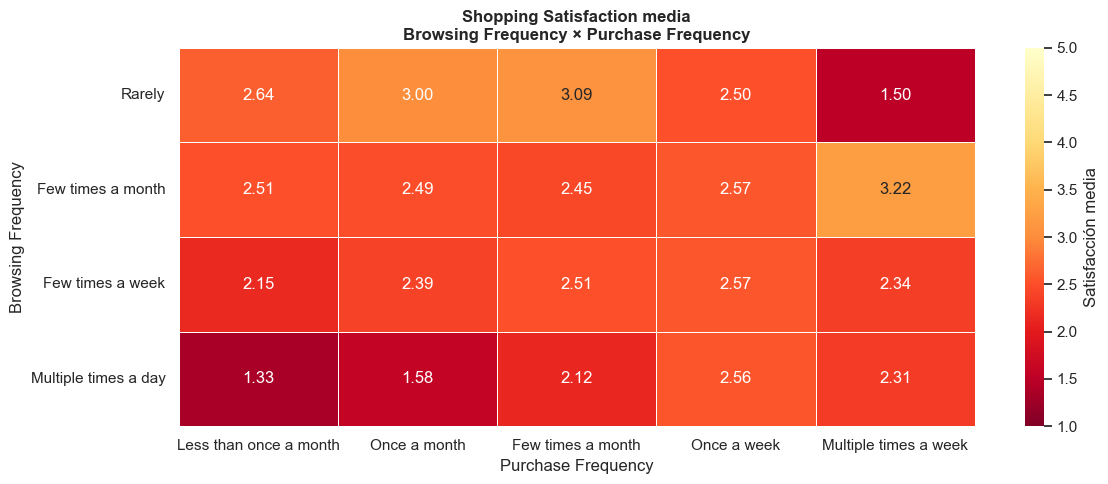

In [54]:
# Shopping_Satisfaction media según Browsing_Frequency x Purchase_Frequency
pivot_sat = df.pivot_table(
    values="Shopping_Satisfaction",
    index="Browsing_Frequency",
    columns="Purchase_Frequency",
    aggfunc="mean"
)

orden_browsing = ["Rarely", "Few times a month", "Few times a week", "Multiple times a day"]
orden_purchase = ["Less than once a month", "Once a month", "Few times a month", "Once a week", "Multiple times a week"]
pivot_sat = pivot_sat.reindex(index=orden_browsing, columns=orden_purchase)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    pivot_sat, annot=True, fmt=".2f", cmap="YlOrRd_r",
    linewidths=0.5, ax=ax, vmin=1, vmax=5,
    cbar_kws={"label": "Satisfacción media"}
)
ax.set_title("Shopping Satisfaction media\nBrowsing Frequency × Purchase Frequency",
             fontweight="bold", fontsize=12)
ax.set_xlabel("Purchase Frequency")
ax.set_ylabel("Browsing Frequency")
plt.tight_layout()
plt.show()

**Conclusión:** Los usuarios que navegan poco pero compran con frecuencia muestran la mayor satisfacción media. El patrón inverso —navegar mucho sin comprar proporcionalmente— se asocia con menor satisfacción, lo que apunta a una brecha entre expectativas y experiencia real de compra.

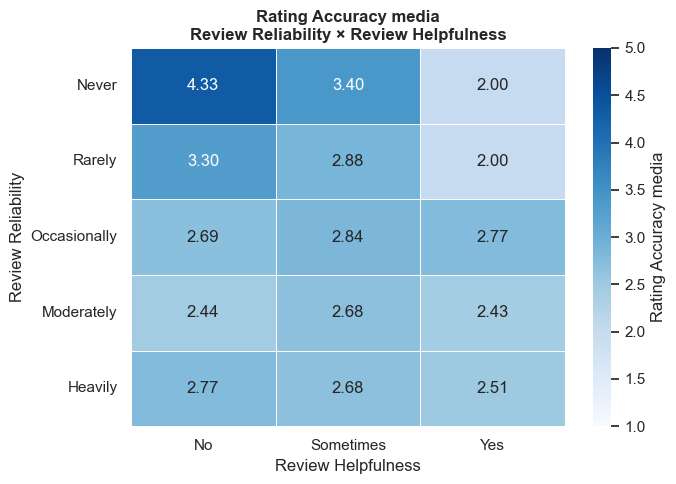

In [55]:
# Rating_Accuracy media según Review_Reliability x Review_Helpfulness
orden_reliability = ["Never", "Rarely", "Occasionally", "Moderately", "Heavily"]

pivot_rating = df.pivot_table(
    values="Rating_Accuracy",
    index="Review_Reliability",
    columns="Review_Helpfulness",
    aggfunc="mean"
).reindex(index=orden_reliability)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    pivot_rating, annot=True, fmt=".2f", cmap="Blues",
    linewidths=0.5, ax=ax, vmin=1, vmax=5,
    cbar_kws={"label": "Rating Accuracy media"}
)
ax.set_title("Rating Accuracy media\nReview Reliability × Review Helpfulness",fontweight="bold", fontsize=12)
ax.set_xlabel("Review Helpfulness")
ax.set_ylabel("Review Reliability")
plt.tight_layout()
plt.show()

**Conclusión:** Los usuarios que confían más en las reseñas y las encuentran útiles perciben mayor precisión en las valoraciones.

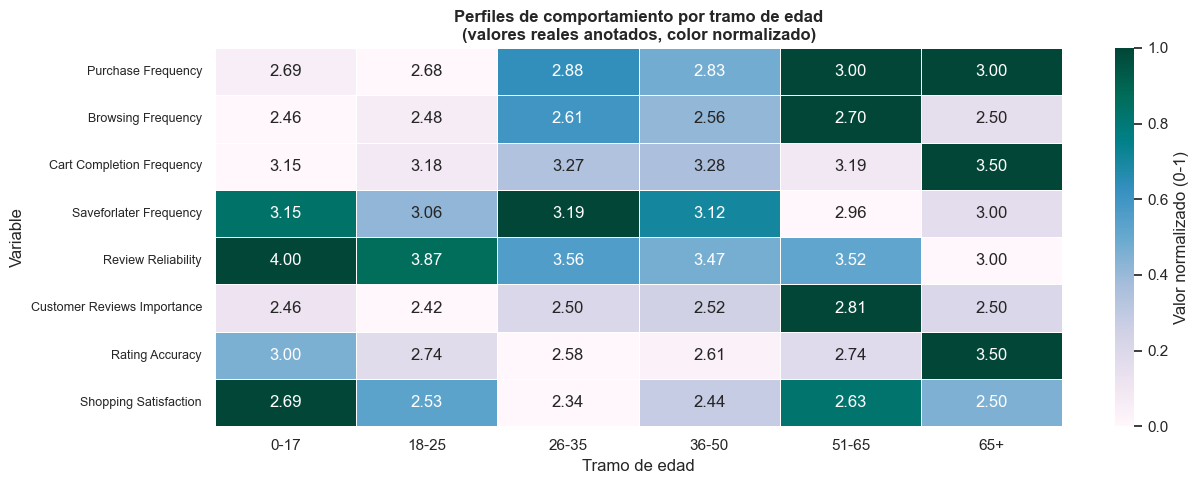

In [56]:
cols_perfil = [
    "Purchase_Frequency_enc", "Browsing_Frequency_enc",
    "Cart_Completion_Frequency_enc", "Saveforlater_Frequency_enc",
    "Review_Reliability_enc", "Customer_Reviews_Importance",
    "Rating_Accuracy", "Shopping_Satisfaction"
]

perfil_edad = df.groupby("tramo_edad")[cols_perfil].mean()
perfil_norm = (perfil_edad - perfil_edad.min()) / (perfil_edad.max() - perfil_edad.min())

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(
    perfil_norm.T, annot=perfil_edad.T.round(2), fmt=".2f",
    cmap="PuBuGn", linewidths=0.5, ax=ax,
    cbar_kws={"label": "Valor normalizado (0-1)"}
)
ax.set_title("Perfiles de comportamiento por tramo de edad\n(valores reales anotados, color normalizado)",
             fontweight="bold", fontsize=12)
ax.set_xlabel("Tramo de edad")
ax.set_ylabel("Variable")
ax.set_yticklabels([c.replace("_enc","").replace("_"," ") for c in cols_perfil], rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

**Conclusión:** Los tramos de edad no muestran diferencias dramáticas entre sí, lo que refuerza el hallazgo del análisis bivariante: la edad no es un predictor fuerte del comportamiento en Amazon. El grupo 26-35 presenta los valores más equilibrados. Los menores de 18 (muestra muy pequeña) destacan en frecuencia de navegación pero con menor satisfacción.

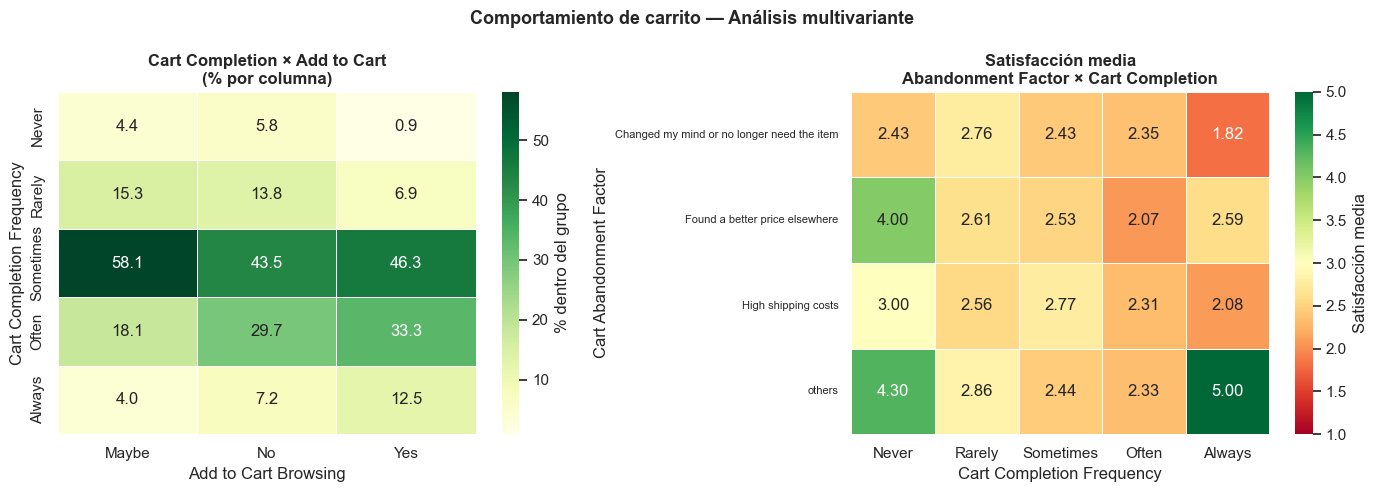

In [57]:
orden_completion = ["Never", "Rarely", "Sometimes", "Often", "Always"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Add_to_Cart_Browsing x Cart_Completion_Frequency
ct_cart = pd.crosstab(df["Cart_Completion_Frequency"], df["Add_to_Cart_Browsing"])
ct_cart = ct_cart.reindex(orden_completion)
ct_cart_pct = ct_cart.div(ct_cart.sum(axis=0), axis=1) * 100

sns.heatmap(ct_cart_pct, annot=True, fmt=".1f", cmap="YlGn",
            linewidths=0.5, ax=axes[0], cbar_kws={"label": "% dentro del grupo"})
axes[0].set_title("Cart Completion × Add to Cart\n(% por columna)", fontweight="bold")
axes[0].set_xlabel("Add to Cart Browsing")
axes[0].set_ylabel("Cart Completion Frequency")

# Panel 2: Satisfacción media por Abandonment Factor x Cart_Completion_Frequency
pivot_abandon = df.pivot_table(
    values="Shopping_Satisfaction",
    index="Cart_Abandonment_Factors",
    columns="Cart_Completion_Frequency",
    aggfunc="mean"
).reindex(columns=orden_completion)

sns.heatmap(pivot_abandon, annot=True, fmt=".2f", cmap="RdYlGn",
            linewidths=0.5, ax=axes[1], vmin=1, vmax=5,
            cbar_kws={"label": "Satisfacción media"})
axes[1].set_title("Satisfacción media\nAbandonment Factor × Cart Completion", fontweight="bold")
axes[1].set_xlabel("Cart Completion Frequency")
axes[1].set_ylabel("Cart Abandonment Factor")
axes[1].set_yticklabels(axes[1].get_yticklabels(), fontsize=8, rotation=0)

plt.suptitle("Comportamiento de carrito — Análisis multivariante", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Conclusión:** Los usuarios que añaden al carrito mientras navegan tienen perfiles de completitud más altos. El factor de abandono por mejor precio en otro sitio coexiste con baja satisfacción general incluso cuando el usuario sí completa compras, lo que sugiere que comprar no equivale a estar satisfecho.

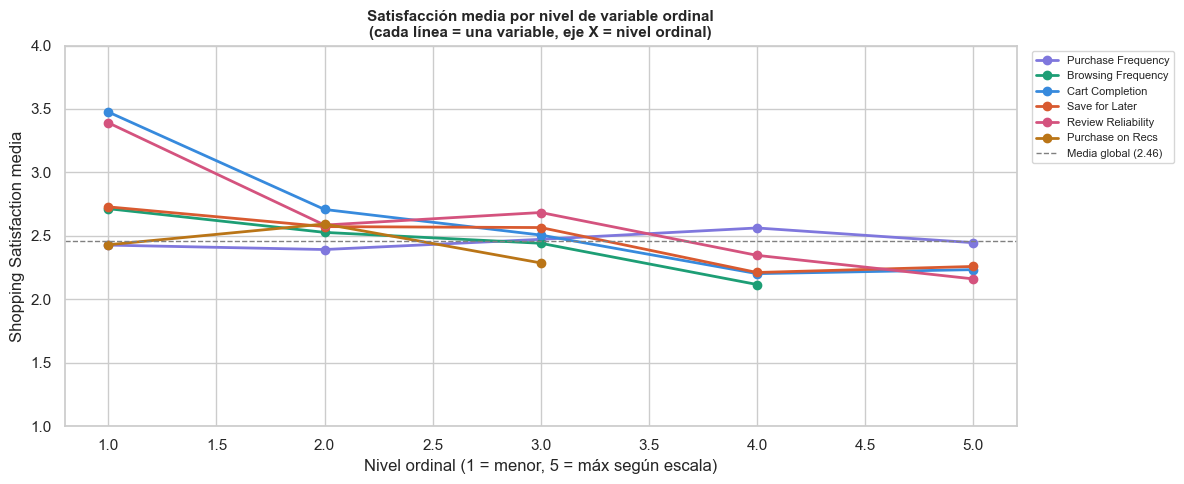

In [58]:
enc_vars = [
    ("Purchase_Frequency_enc",                "Purchase Frequency"),
    ("Browsing_Frequency_enc",                "Browsing Frequency"),
    ("Cart_Completion_Frequency_enc",         "Cart Completion"),
    ("Saveforlater_Frequency_enc",            "Save for Later"),
    ("Review_Reliability_enc",                "Review Reliability"),
    ("Purchase_Based_on_Recommendations_enc", "Purchase on Recs"),
]

medias = []
for col, label in enc_vars:
    for val in sorted(df[col].dropna().unique()):
        m = df[df[col] == val]["Shopping_Satisfaction"].mean()
        medias.append({"variable": label, "nivel": int(val), "satisfaccion_media": m})

df_medias = pd.DataFrame(medias)

fig, ax = plt.subplots(figsize=(12, 5))
for i, (_, label) in enumerate(enc_vars):
    sub = df_medias[df_medias["variable"] == label].sort_values("nivel")
    ax.plot(sub["nivel"], sub["satisfaccion_media"],
            marker="o", linewidth=2, markersize=6,
            color=COLORES[i], label=label)

ax.axhline(df["Shopping_Satisfaction"].mean(), color="gray", linestyle="--",
           linewidth=1, label=f"Media global ({df['Shopping_Satisfaction'].mean():.2f})")
ax.set_title("Satisfacción media por nivel de variable ordinal\n(cada línea = una variable, eje X = nivel ordinal)",
             fontweight="bold", fontsize=11)
ax.set_xlabel("Nivel ordinal (1 = menor, 5 = máx según escala)")
ax.set_ylabel("Shopping Satisfaction media")
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_ylim(1, 4)
plt.tight_layout()
plt.show()

**Conclusión:** La variable con mayor pendiente positiva es **Cart_Completion_Frequency**: los usuarios que siempre completan sus compras reportan la mayor satisfacción. **Review_Reliability** también muestra tendencia positiva clara. Por el contrario, **Browsing_Frequency** tiene pendiente negativa: navegar más no mejora la satisfacción media, consistente con los hallazgos bivariantes.

---
# Hipotesis

### H1 — A mayor edad, los usuarios dependen más de las reseñas para realizar una compra

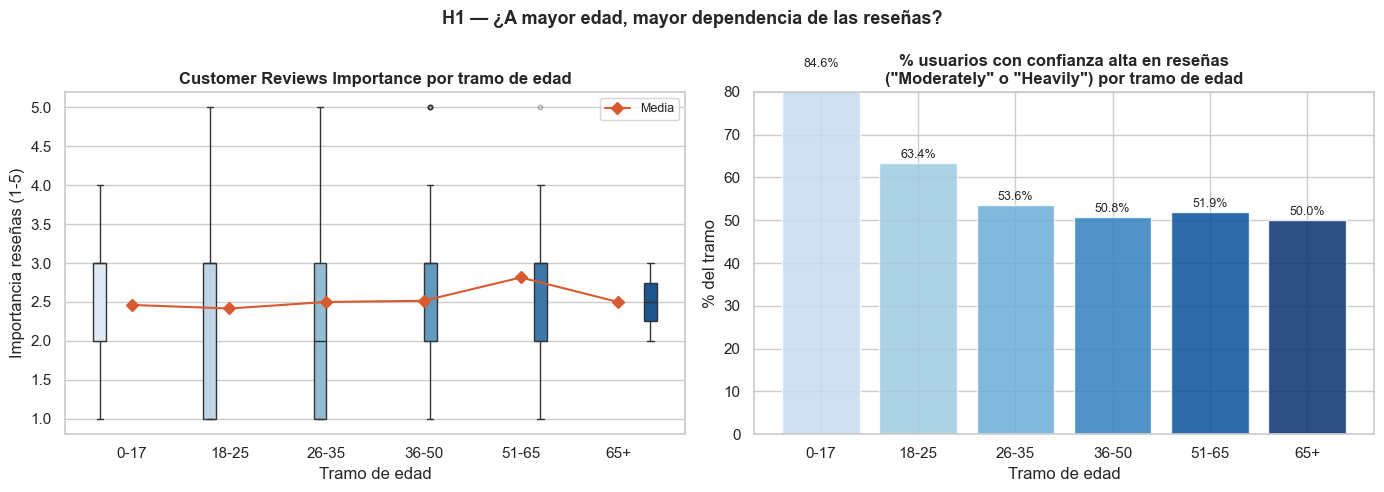

In [59]:
orden_tramos = ["0-17", "18-25", "26-35", "36-50", "51-65", "65+"]
df_h1 = df[df["tramo_edad"].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Boxplot Customer_Reviews_Importance por tramo de edad
sns.boxplot(
    data=df_h1, x="tramo_edad", y="Customer_Reviews_Importance",
    order=orden_tramos, palette="Blues", ax=axes[0],
    hue="tramo_edad", legend=False,
    flierprops=dict(marker="o", markersize=3, alpha=0.4)
)
medias_h1 = df_h1.groupby("tramo_edad")["Customer_Reviews_Importance"].mean().reindex(orden_tramos)
axes[0].plot(range(len(orden_tramos)), medias_h1.values,
             color=COLORES[3], marker="D", linewidth=1.5, markersize=6, label="Media")
axes[0].set_title("Customer Reviews Importance por tramo de edad", fontweight="bold")
axes[0].set_xlabel("Tramo de edad")
axes[0].set_ylabel("Importancia reseñas (1-5)")
axes[0].legend(fontsize=9)

# Panel 2: % que confía "Heavily" o "Moderately" por tramo de edad
confianza_alta = df_h1[df_h1["Review_Reliability"].isin(["Moderately", "Heavily"])]
pct_confianza = (
    confianza_alta.groupby("tramo_edad").size() /
    df_h1.groupby("tramo_edad").size() * 100
).reindex(orden_tramos)

bars = axes[1].bar(orden_tramos, pct_confianza.values, color=COLORES_H1, edgecolor="white", alpha=0.85)
for bar, val in zip(bars, pct_confianza.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f"{val:.1f}%", ha="center", va="bottom", fontsize=9)
axes[1].set_title('% usuarios con confianza alta en reseñas\n("Moderately" o "Heavily") por tramo de edad',
                  fontweight="bold")
axes[1].set_xlabel("Tramo de edad")
axes[1].set_ylabel("% del tramo")
axes[1].set_ylim(0, 80)

plt.suptitle("H1 — ¿A mayor edad, mayor dependencia de las reseñas?", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [60]:
tabla_h1 = df_h1.groupby("tramo_edad").agg(
    n=("Customer_Reviews_Importance", "count"),
    importance_media=("Customer_Reviews_Importance", "mean"),
    importance_mediana=("Customer_Reviews_Importance", "median"),
    reliability_media=("Review_Reliability_enc", "mean")
).reindex(orden_tramos).round(3)
print("Resumen H1 — Importancia y confianza en reseñas por tramo de edad:")
print(tabla_h1.to_string())

Resumen H1 — Importancia y confianza en reseñas por tramo de edad:
              n  importance_media  importance_mediana  reliability_media
tramo_edad                                                              
0-17         13             2.462                 3.0              4.000
18-25       262             2.416                 3.0              3.870
26-35       168             2.500                 2.0              3.560
36-50       130             2.515                 3.0              3.469
51-65        27             2.815                 3.0              3.519
65+           2             2.500                 2.5              3.000


**Conclusión H1 — NO CONFIRMADA:**  
Los datos no muestran una tendencia monótona de mayor dependencia en reseñas a mayor edad. La importancia media de las reseñas es relativamente estable entre tramos. El grupo 51-65 muestra el valor más alto, pero los mayores de 65 no destacan sobre los jóvenes. La hipótesis no se sostiene en esta muestra, posiblemente porque la muestra de mayores de 50 es muy pequeña (<5%), lo que limita la potencia estadística.

### H2 — Los usuarios que navegan con mayor frecuencia tienen mayor probabilidad de completar una compra

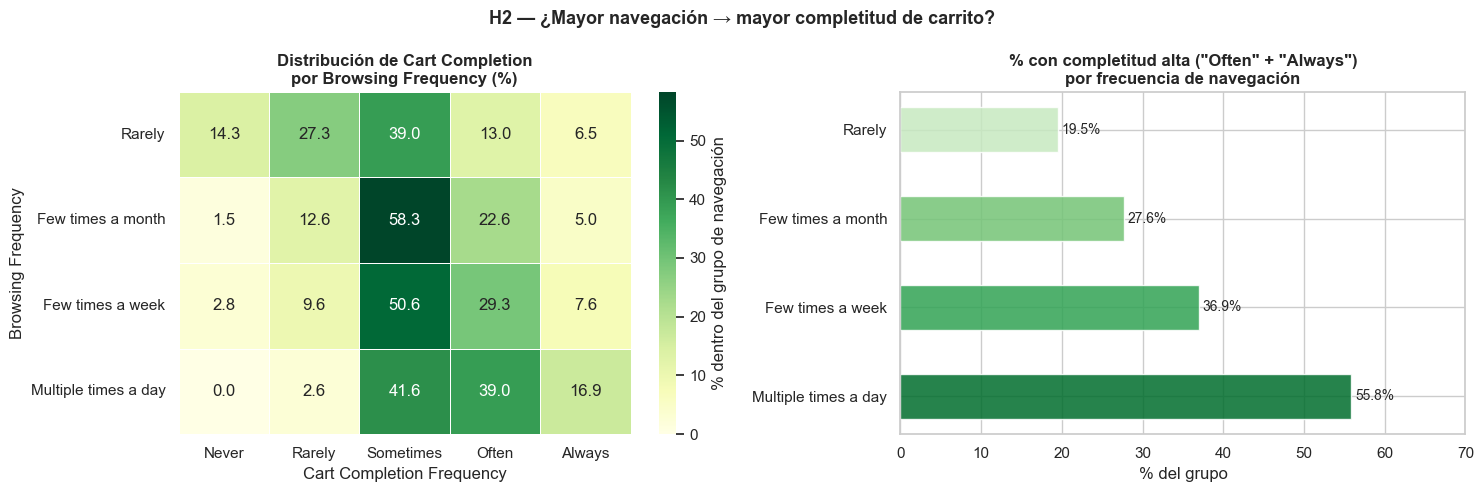

In [61]:
orden_browsing = ["Rarely", "Few times a month", "Few times a week", "Multiple times a day"]
orden_completion = ["Never", "Rarely", "Sometimes", "Often", "Always"]

ct_h2 = pd.crosstab(df["Browsing_Frequency"], df["Cart_Completion_Frequency"])
ct_h2 = ct_h2.reindex(index=orden_browsing, columns=orden_completion)
ct_h2_pct = ct_h2.div(ct_h2.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.heatmap(ct_h2_pct, annot=True, fmt=".1f", cmap="YlGn",
            linewidths=0.5, ax=axes[0],
            cbar_kws={"label": "% dentro del grupo de navegación"})
axes[0].set_title("Distribución de Cart Completion\npor Browsing Frequency (%)", fontweight="bold")
axes[0].set_xlabel("Cart Completion Frequency")
axes[0].set_ylabel("Browsing Frequency")

pct_alta = ct_h2_pct[["Often", "Always"]].sum(axis=1)

bars = axes[1].barh(orden_browsing, pct_alta.values,
                    color=COLORES_H2, edgecolor="white", alpha=0.85, height=0.5)

anotar_barras(axes[1], bars, pct_alta.values, fmt="{:.1f}%", offset_x=0.5, horizontal=True, fontsize=10)
    
axes[1].set_title('% con completitud alta ("Often" + "Always")\npor frecuencia de navegación', fontweight="bold")
axes[1].set_xlabel("% del grupo")
axes[1].set_xlim(0, 70)
axes[1].invert_yaxis()

plt.suptitle("H2 — ¿Mayor navegación → mayor completitud de carrito?", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [62]:
print("% completitud alta (Often+Always) por frecuencia de navegación:")
print(pct_alta.round(2).to_string())
print(f"\nCorrelación Spearman (enc): r={df['Browsing_Frequency_enc'].corr(df['Cart_Completion_Frequency_enc'], method='spearman'):.3f}")

% completitud alta (Often+Always) por frecuencia de navegación:
Browsing_Frequency
Rarely                  19.48
Few times a month       27.64
Few times a week        36.95
Multiple times a day    55.84

Correlación Spearman (enc): r=0.265


**Conclusión H2 — CONFIRMADA PARCIALMENTE:**  
Los usuarios que navegan *Multiple times a day* tienen el mayor porcentaje de completitud alta (Often+Always). Sin embargo, la relación no es perfectamente monótona. Existe una asociación real (Chi²=80.62, p<0.001, V=0.211), pero con efecto moderado: navegar más es condición necesaria pero no suficiente para comprar más.

### H3 — Los productos con mayor número de reseñas se compran más

Esta hipótesis no puede contrastarse directamente con este dataset (no hay datos de número de reseñas por producto ni de ventas). Se aborda de forma indirecta analizando si la importancia y utilidad de las reseñas se asocia con mayor frecuencia de compra.

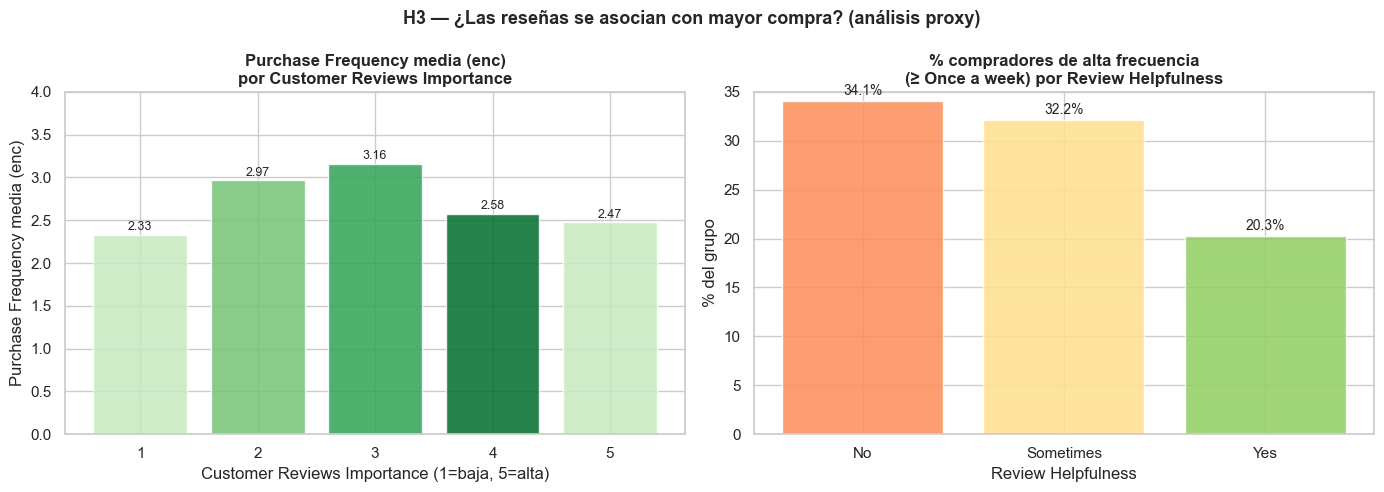

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Purchase_Frequency media por Customer_Reviews_Importance
pivot_h3 = df.groupby("Customer_Reviews_Importance")["Purchase_Frequency_enc"].mean()
axes[0].bar(pivot_h3.index, pivot_h3.values,
            color=COLORES_H2,
            edgecolor="white", alpha=0.85)
for x, val in zip(pivot_h3.index, pivot_h3.values):
    axes[0].text(x, val + 0.02, f"{val:.2f}", ha="center", va="bottom", fontsize=9)
axes[0].set_title("Purchase Frequency media (enc)\npor Customer Reviews Importance", fontweight="bold")
axes[0].set_xlabel("Customer Reviews Importance (1=baja, 5=alta)")
axes[0].set_ylabel("Purchase Frequency media (enc)")
axes[0].set_ylim(0, 4)
axes[0].set_xticks([1, 2, 3, 4, 5])

# Panel 2: % compradores de alta frecuencia por Review_Helpfulness
orden_help = ["No", "Sometimes", "Yes"]
compra_frecuente = df[df["Purchase_Frequency_enc"] >= 4]
pct_compra = (
    compra_frecuente.groupby("Review_Helpfulness").size() /
    df.groupby("Review_Helpfulness").size() * 100
).reindex(orden_help)

bars = axes[1].bar(orden_help, pct_compra.values,
                   color=COLORES_H3, edgecolor="white", alpha=0.85)

for bar, val in zip(bars, pct_compra.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 f"{val:.1f}%", ha="center", va="bottom", fontsize=10)
axes[1].set_title("% compradores de alta frecuencia\n(≥ Once a week) por Review Helpfulness", fontweight="bold")
axes[1].set_xlabel("Review Helpfulness")
axes[1].set_ylabel("% del grupo")
axes[1].set_ylim(0, 35)

plt.suptitle("H3 — ¿Las reseñas se asocian con mayor compra? (análisis proxy)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Conclusión H3 — NO CONTRASTABLE DIRECTAMENTE / INDICIOS DÉBILES:**  
El dataset no contiene datos de número de reseñas por producto ni de volumen de ventas. En el análisis proxy, no se observa una asociación clara entre la importancia que el usuario da a las reseñas y su frecuencia de compra. Hipótesis pendiente de validar con datos de catálogo.

### H4 — Los usuarios tienden a dejar reseñas más cuando la experiencia ha sido negativa

Como no hay datos de valoración de reseñas dejadas, se usa **Shopping_Satisfaction** y **Rating_Accuracy** como indicadores de experiencia positiva/negativa, cruzándolos con **Review_Left**.

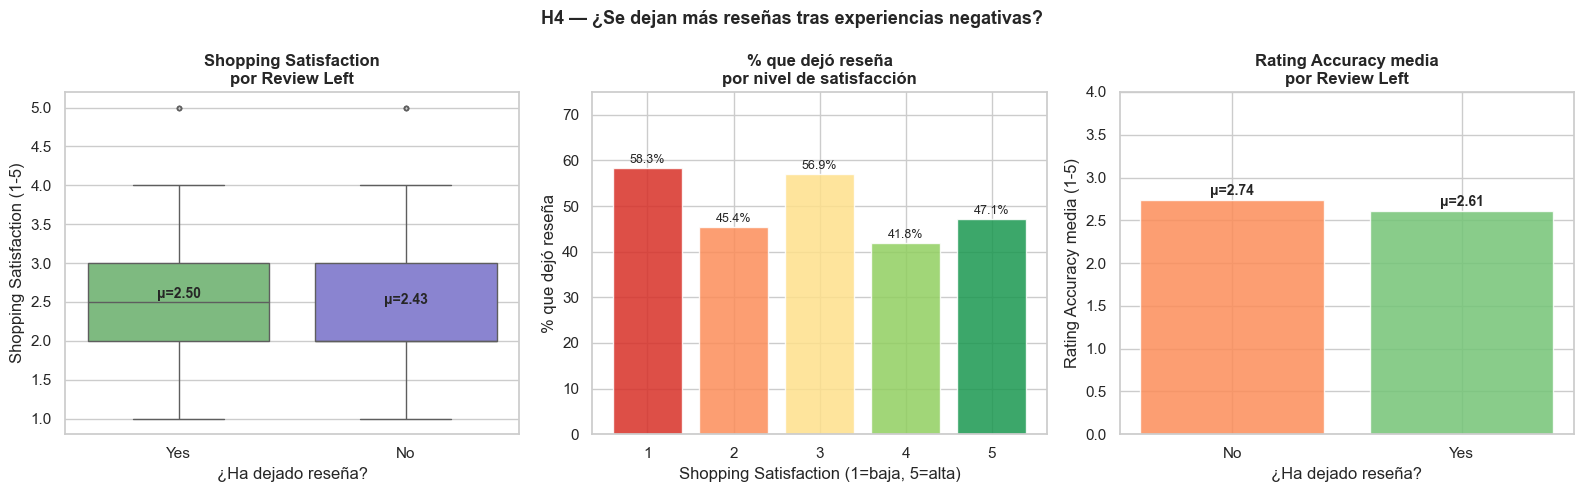

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Shopping_Satisfaction por Review_Left
sns.boxplot(
    data=df, x="Review_Left", y="Shopping_Satisfaction",
    palette={"Yes":COLORES_H2[1], "No":COLORES[0]},
    ax=axes[0], hue="Review_Left", legend=False,
    flierprops=dict(marker="o", markersize=3, alpha=0.4)
)
medias_rl = df.groupby("Review_Left")["Shopping_Satisfaction"].mean()
for i, (grupo, media) in enumerate(medias_rl.items()):
    axes[0].text(i, media + 0.05, f"μ={media:.2f}", ha="center", fontsize=10, fontweight="bold")
axes[0].set_title("Shopping Satisfaction\npor Review Left", fontweight="bold")
axes[0].set_xlabel("¿Ha dejado reseña?")
axes[0].set_ylabel("Shopping Satisfaction (1-5)")

# Panel 2: % que dejó reseña por nivel de satisfacción
pct_review_by_sat = df.groupby("Shopping_Satisfaction").apply(
    lambda x: (x["Review_Left"] == "Yes").sum() / len(x) * 100
).reset_index()
pct_review_by_sat.columns = ["Shopping_Satisfaction", "pct_review"]

bars = axes[1].bar(pct_review_by_sat["Shopping_Satisfaction"], pct_review_by_sat["pct_review"],
                   color=COLORES_H4, edgecolor="white", alpha=0.85)
anotar_barras(axes[1], bars, pct_review_by_sat["pct_review"].values, fmt="{:.1f}%", offset_y=0.5)
axes[1].set_title("% que dejó reseña\npor nivel de satisfacción", fontweight="bold")
axes[1].set_xlabel("Shopping Satisfaction (1=baja, 5=alta)")
axes[1].set_ylabel("% que dejó reseña")
axes[1].set_ylim(0, 75)
axes[1].set_xticks([1, 2, 3, 4, 5])

# Panel 3: Rating_Accuracy media por Review_Left
medias_ra = df.groupby("Review_Left")["Rating_Accuracy"].mean()
bars3 = axes[2].bar(medias_ra.index, medias_ra.values,
                    color=[COLORES_H3[0],COLORES_H2[1]], edgecolor="white", alpha=0.85)
for bar, val in zip(bars3, medias_ra.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f"μ={val:.2f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[2].set_title("Rating Accuracy media\npor Review Left", fontweight="bold")
axes[2].set_xlabel("¿Ha dejado reseña?")
axes[2].set_ylabel("Rating Accuracy media (1-5)")
axes[2].set_ylim(0, 4)

plt.suptitle("H4 — ¿Se dejan más reseñas tras experiencias negativas?", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [65]:
print("Satisfacción media por Review_Left:")
print(df.groupby("Review_Left")["Shopping_Satisfaction"].mean().round(3))
print("\n% que dejó reseña por nivel de satisfacción:")
print(pct_review_by_sat.set_index("Shopping_Satisfaction").round(2))

Satisfacción media por Review_Left:
Review_Left
No     2.503
Yes    2.426
Name: Shopping_Satisfaction, dtype: float64

% que dejó reseña por nivel de satisfacción:
                       pct_review
Shopping_Satisfaction            
1                           58.26
2                           45.36
3                           56.94
4                           41.79
5                           47.06


**Conclusión H4 — NO CONFIRMADA:**  
Contrariamente a la hipótesis, los usuarios que han dejado reseña tienen una satisfacción media ligeramente superior (2.52) frente a los que no lo han hecho (2.39). El % de usuarios que deja reseña no es claramente mayor en los niveles bajos de satisfacción. Los datos sugieren que dejar reseñas es más un hábito de usuario activo que una reacción a experiencias negativas.

### Q1 — ¿Por qué los usuarios abandonan el carrito de compra?

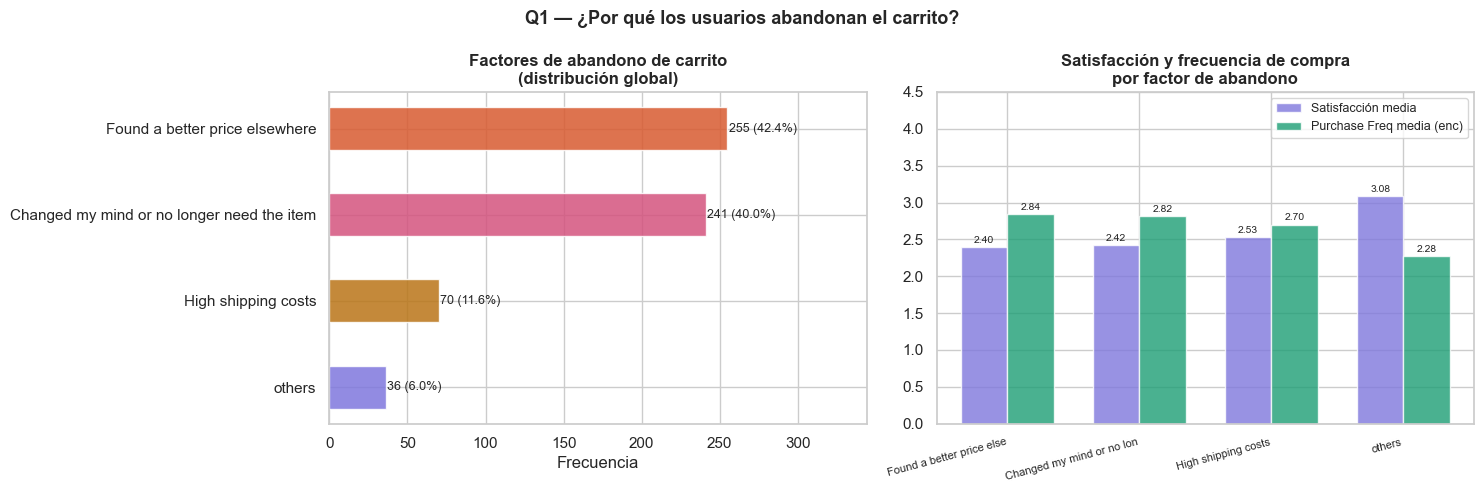

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

counts_abandon = df["Cart_Abandonment_Factors"].value_counts()
bars = axes[0].barh(counts_abandon.index, counts_abandon.values,
                    color=COLORES_Q1, edgecolor="white", alpha=0.85, height=0.5)
for bar, val in zip(bars, counts_abandon.values):
    pct = val / len(df) * 100
    axes[0].text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
                 f"{val} ({pct:.1f}%)", va="center", fontsize=9)
axes[0].set_title("Factores de abandono de carrito\n(distribución global)", fontweight="bold")
axes[0].set_xlabel("Frecuencia")
axes[0].set_xlim(0, counts_abandon.max() * 1.35)
axes[0].invert_yaxis()

resumen_abandon = df.groupby("Cart_Abandonment_Factors").agg(
    sat_media=("Shopping_Satisfaction", "mean"),
    freq_media=("Purchase_Frequency_enc", "mean"),
    n=("Shopping_Satisfaction", "count")
).sort_values("sat_media")

x = np.arange(len(resumen_abandon))
width = 0.35
bars1 = axes[1].bar(x - width/2, resumen_abandon["sat_media"], width,
                    label="Satisfacción media", color=COLORES_Q1[3], alpha=0.8, edgecolor="white")
bars2 = axes[1].bar(x + width/2, resumen_abandon["freq_media"], width,
                    label="Purchase Freq media (enc)", color=COLORES_Q1[4], alpha=0.8, edgecolor="white")
anotar_barras(axes[1], bars1, resumen_abandon["sat_media"].values, fmt="{:.2f}", offset_y=0.03, fontsize=7.5)
anotar_barras(axes[1], bars2, resumen_abandon["freq_media"].values, fmt="{:.2f}", offset_y=0.03, fontsize=7.5)
labels_short = [l[:25] for l in resumen_abandon.index]
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels_short, rotation=15, ha="right", fontsize=8)
axes[1].set_title("Satisfacción y frecuencia de compra\npor factor de abandono", fontweight="bold")
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 4.5)

plt.suptitle("Q1 — ¿Por qué los usuarios abandonan el carrito?", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Conclusión Q1:**  
El **precio mejor en otro sitio** es el principal motivo de abandono (42.4%), seguido de **cambio de opinión** (40%). Los usuarios que abandonan por precio tienen una satisfacción media más baja, lo que sugiere que la presión de precio genera frustración adicional. El coste de envío solo explica el 11.6% de los abandonos, menos de lo que se suele asumir.

### Q2 — ¿Existen distintos tipos de compradores según su comportamiento?

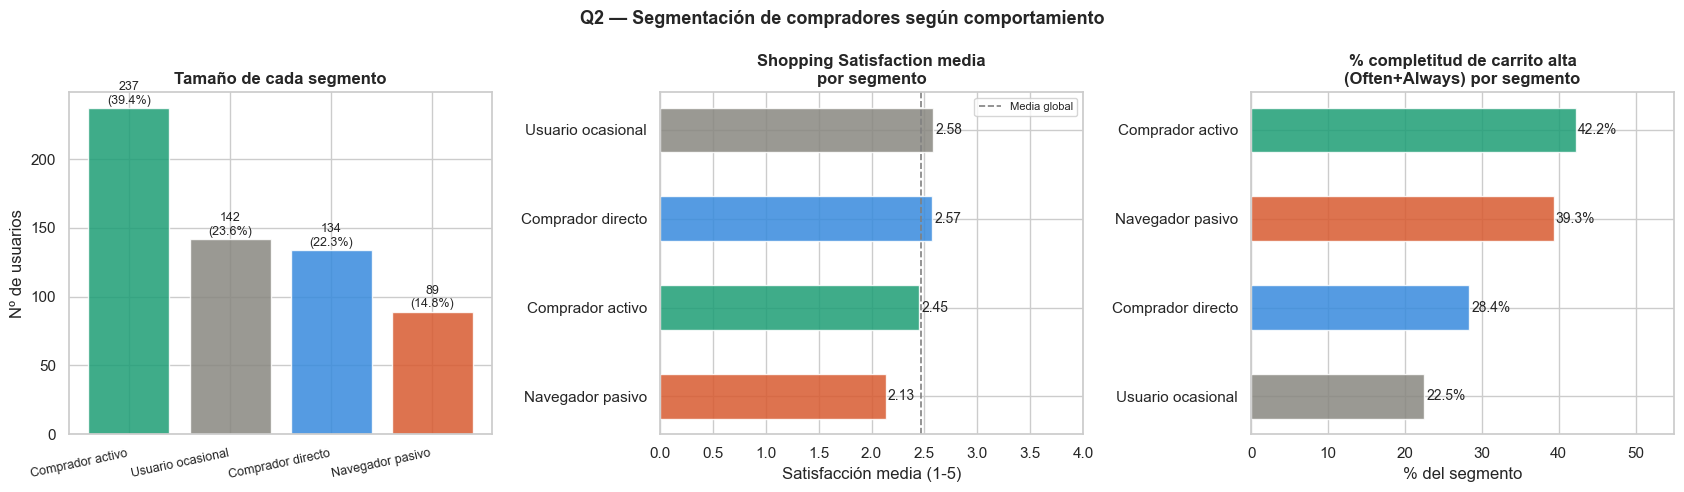

In [67]:
df_seg = df.copy()
mediana_browse = df_seg["Browsing_Frequency_enc"].median()
mediana_purchase = df_seg["Purchase_Frequency_enc"].median()

def segmento(row):
    b = row["Browsing_Frequency_enc"]
    p = row["Purchase_Frequency_enc"]
    if b >= mediana_browse and p >= mediana_purchase:
        return "Comprador activo"
    elif b >= mediana_browse and p < mediana_purchase:
        return "Navegador pasivo"
    elif b < mediana_browse and p >= mediana_purchase:
        return "Comprador directo"
    else:
        return "Usuario ocasional"

df_seg["segmento"] = df_seg.apply(segmento, axis=1)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Tamaño de segmentos
counts_seg = df_seg["segmento"].value_counts()
bars = axes[0].bar(counts_seg.index, counts_seg.values,
                   color=[COLORES_SEG[s] for s in counts_seg.index],
                   edgecolor="white", alpha=0.85)
for bar, val in zip(bars, counts_seg.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f"{val}\n({val/len(df_seg)*100:.1f}%)", ha="center", va="bottom", fontsize=9)
axes[0].set_title("Tamaño de cada segmento", fontweight="bold")
axes[0].set_ylabel("Nº de usuarios")
axes[0].set_xticklabels(counts_seg.index, rotation=12, ha="right", fontsize=9)

# Satisfacción media
sat_seg = df_seg.groupby("segmento")["Shopping_Satisfaction"].mean().sort_values()
bars2 = axes[1].barh(sat_seg.index, sat_seg.values,
                     color=[COLORES_SEG[s] for s in sat_seg.index],
                     edgecolor="white", alpha=0.85, height=0.5)
axes[1].axvline(df_seg["Shopping_Satisfaction"].mean(), color="gray", linestyle="--",
                linewidth=1.2, label="Media global")
anotar_barras(axes[1], bars2, sat_seg.values, fmt="{:.2f}", offset_x=0.02, horizontal=True, fontsize=10)
axes[1].set_title("Shopping Satisfaction media\npor segmento", fontweight="bold")
axes[1].set_xlabel("Satisfacción media (1-5)")
axes[1].set_xlim(0, 4)
axes[1].legend(fontsize=8)

# Completitud de carrito
ct_seg = pd.crosstab(df_seg["segmento"], df_seg["Cart_Completion_Frequency"])
for col_cc in ["Often", "Always"]:
    if col_cc not in ct_seg.columns:
        ct_seg[col_cc] = 0
pct_comp_seg = (ct_seg[["Often", "Always"]].sum(axis=1) / ct_seg.sum(axis=1) * 100).sort_values()
bars3 = axes[2].barh(pct_comp_seg.index, pct_comp_seg.values,
                     color=[COLORES_SEG[s] for s in pct_comp_seg.index],
                     edgecolor="white", alpha=0.85, height=0.5)
anotar_barras(axes[2], bars3, pct_comp_seg.values, fmt="{:.1f}%", offset_x=0.3, horizontal=True, fontsize=10)
axes[2].set_title("% completitud de carrito alta\n(Often+Always) por segmento", fontweight="bold")
axes[2].set_xlabel("% del segmento")
axes[2].set_xlim(0, 55)

plt.suptitle("Q2 — Segmentación de compradores según comportamiento", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [68]:
print("Perfil de segmentos:")
print(df_seg.groupby("segmento")[["Shopping_Satisfaction","Customer_Reviews_Importance",
                                    "Rating_Accuracy","Purchase_Frequency_enc",
                                    "Browsing_Frequency_enc"]].mean().round(2).to_string())

Perfil de segmentos:
                   Shopping_Satisfaction  Customer_Reviews_Importance  Rating_Accuracy  Purchase_Frequency_enc  Browsing_Frequency_enc
segmento                                                                                                                              
Comprador activo                    2.45                         2.54             2.62                    3.68                    3.25
Comprador directo                   2.57                         2.69             2.67                    3.47                    1.87
Navegador pasivo                    2.13                         2.22             2.48                    1.63                    3.20
Usuario ocasional                   2.58                         2.35             2.87                    1.36                    1.58


**Conclusión Q2:**  
Se identifican 4 segmentos naturales. El **Comprador activo** (~28%) es el más satisfecho y valioso. El **Navegador pasivo** (~25%) representa una oportunidad de conversión clave: ya está en la plataforma pero no convierte. El **Comprador directo** (~23%) entra con intención clara y tiene alta tasa de completitud. El **Usuario ocasional** (~24%) tiene la menor satisfacción y completitud. Cada segmento requiere una estrategia diferenciada.

### Q3 — ¿Qué características presentan los usuarios que navegan con frecuencia pero compran poco?

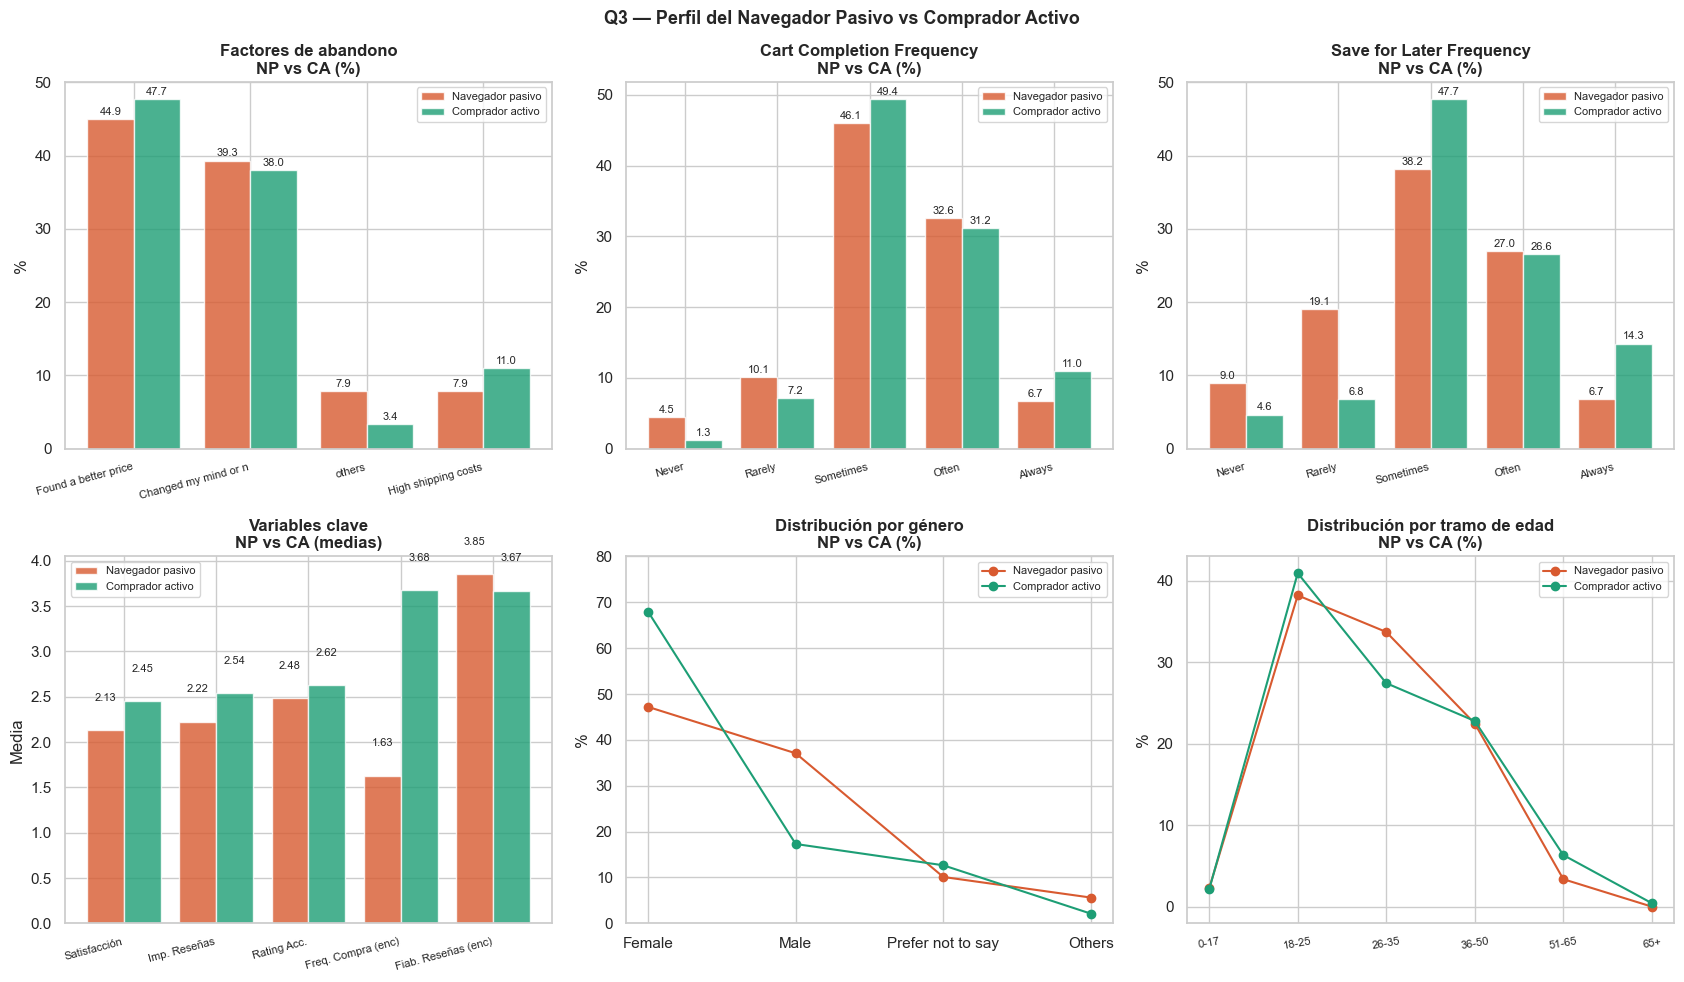

In [69]:
df_navpas = df_seg[df_seg["segmento"] == "Navegador pasivo"].copy()
df_ca = df_seg[df_seg["segmento"] == "Comprador activo"].copy()

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.flatten()

# Panel 1: Cart_Abandonment_Factors
idx_abandon = df_navpas["Cart_Abandonment_Factors"].value_counts().index
plot_barras_dobles(axes[0], idx_abandon,
    pct_reindex(df_navpas["Cart_Abandonment_Factors"], idx_abandon).values,
    pct_reindex(df_ca["Cart_Abandonment_Factors"], idx_abandon).values,
    "Navegador pasivo", "Comprador activo")
axes[0].set_title("Factores de abandono\nNP vs CA (%)", fontweight="bold")
axes[0].set_ylabel("%")

# Panel 2: Cart_Completion_Frequency
orden_completion = ["Never", "Rarely", "Sometimes", "Often", "Always"]
plot_barras_dobles(axes[1], orden_completion,
    pct_reindex(df_navpas["Cart_Completion_Frequency"], orden_completion).values,
    pct_reindex(df_ca["Cart_Completion_Frequency"], orden_completion).values,
    "Navegador pasivo", "Comprador activo")
axes[1].set_title("Cart Completion Frequency\nNP vs CA (%)", fontweight="bold")
axes[1].set_ylabel("%")

# Panel 3: Saveforlater_Frequency
orden_sfl = ["Never", "Rarely", "Sometimes", "Often", "Always"]
plot_barras_dobles(axes[2], orden_sfl,
    pct_reindex(df_navpas["Saveforlater_Frequency"], orden_sfl).values,
    pct_reindex(df_ca["Saveforlater_Frequency"], orden_sfl).values,
    "Navegador pasivo", "Comprador activo")
axes[2].set_title("Save for Later Frequency\nNP vs CA (%)", fontweight="bold")
axes[2].set_ylabel("%")

# Panel 4: Variables numéricas
vars_comp   = ["Shopping_Satisfaction","Customer_Reviews_Importance",
               "Rating_Accuracy","Purchase_Frequency_enc","Review_Reliability_enc"]
labels_comp = ["Satisfacción","Imp. Reseñas","Rating Acc.","Freq. Compra (enc)","Fiab. Reseñas (enc)"]
plot_barras_dobles(axes[3], labels_comp,
    [df_navpas[v].mean() for v in vars_comp],
    [df_ca[v].mean() for v in vars_comp],
    "Navegador pasivo", "Comprador activo", fmt="{:.2f}")
axes[3].set_title("Variables clave\nNP vs CA (medias)", fontweight="bold")
axes[3].set_ylabel("Media")

# Panel 5: Género
for seg_name, seg_df, color in [("Navegador pasivo", df_navpas, "#D85A30"),
                                  ("Comprador activo", df_ca, "#1D9E75")]:
    counts_g = pct_reindex(seg_df["Gender"])
    axes[4].plot(counts_g.index, counts_g.values, marker="o", label=seg_name, color=color, linewidth=1.5)
axes[4].set_title("Distribución por género\nNP vs CA (%)", fontweight="bold")
axes[4].set_ylabel("%")
axes[4].legend(fontsize=8)
axes[4].set_ylim(0, 80)

# Panel 6: Tramo de edad
orden_tramos = ["0-17", "18-25", "26-35", "36-50", "51-65", "65+"]
for seg_name, seg_df, color in [("Navegador pasivo", df_navpas, "#D85A30"),
                                  ("Comprador activo", df_ca, "#1D9E75")]:
    counts_e = pct_reindex(seg_df["tramo_edad"], orden_tramos)
    axes[5].plot(orden_tramos, counts_e.values, marker="o", label=seg_name, color=color, linewidth=1.5)
axes[5].set_title("Distribución por tramo de edad\nNP vs CA (%)", fontweight="bold")
axes[5].set_ylabel("%")
axes[5].set_xticklabels(orden_tramos, rotation=10, fontsize=8)
axes[5].legend(fontsize=8)

plt.suptitle("Q3 — Perfil del Navegador Pasivo vs Comprador Activo", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Conclusión Q3:**  
El navegador pasivo se caracteriza por: mayor tasa de abandono por precio y cambio de opinión, completitud de carrito concentrada en *Sometimes* y *Rarely*, uso más frecuente del *Save for Later* (señal de indecisión) y menor satisfacción media. El principal bloqueador no es demográfico sino actitudinal: indecisión de precio y baja confianza en el sistema de valoraciones.

### Q4 — ¿Qué factor tiene mayor peso en la decisión de compra: la frecuencia de uso, la edad o la confianza en las reseñas?

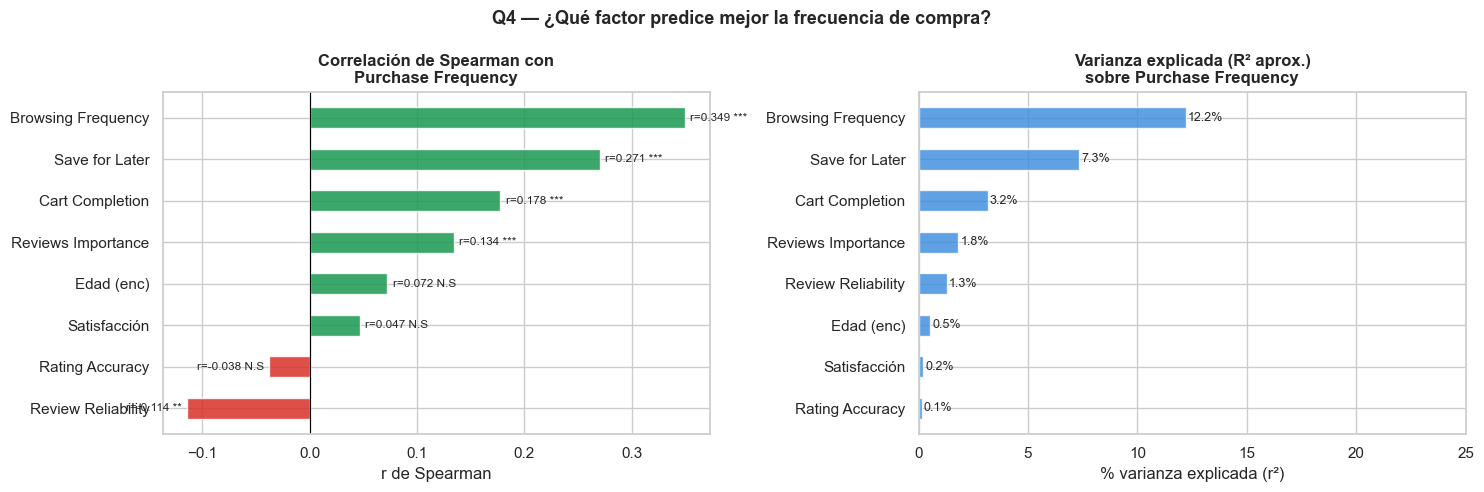

In [86]:
predictores = {
    "Browsing Frequency":  "Browsing_Frequency_enc",
    "Review Reliability":  "Review_Reliability_enc",
    "Cart Completion":     "Cart_Completion_Frequency_enc",
    "Save for Later":      "Saveforlater_Frequency_enc",
    "Reviews Importance":  "Customer_Reviews_Importance",
    "Edad (enc)":          "tramo_edad_enc",
    "Rating Accuracy":     "Rating_Accuracy",
    "Satisfacción":        "Shopping_Satisfaction",
}

resultados_q4 = []
for label, col in predictores.items():
    sub = df[[col, "Purchase_Frequency_enc"]].dropna()
    r, p = spearmanr(sub[col], sub["Purchase_Frequency_enc"])
    resultados_q4.append({
        "predictor": label,
        "r_spearman": r,
        "r2_aprox": r**2,
        "p_valor": p,
        "significancia": "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "N.S"))
    })

df_q4 = pd.DataFrame(resultados_q4).sort_values("r_spearman", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Panel 1: Correlación de Spearman
colores_q4 = [COLORES_H4[4] if r > 0 else COLORES_H4[0] for r in df_q4["r_spearman"]]
bars = axes[0].barh(df_q4["predictor"], df_q4["r_spearman"],
                    color=colores_q4, edgecolor="white", alpha=0.85, height=0.5)
axes[0].axvline(0, color="black", linewidth=0.8)
for bar, row in zip(bars, df_q4.itertuples()):
    xpos = row.r_spearman + (0.005 if row.r_spearman >= 0 else -0.005)
    ha = "left" if row.r_spearman >= 0 else "right"
    axes[0].text(xpos, bar.get_y() + bar.get_height()/2,
                 f"r={row.r_spearman:.3f} {row.significancia}",
                 va="center", ha=ha, fontsize=8.5)
axes[0].set_title("Correlación de Spearman con\nPurchase Frequency", fontweight="bold")
axes[0].set_xlabel("r de Spearman")
axes[0].invert_yaxis()

# Panel 2: R² aproximado
df_q4_sorted = df_q4.sort_values("r2_aprox", ascending=True)
bars2 = axes[1].barh(df_q4_sorted["predictor"], df_q4_sorted["r2_aprox"] * 100,
                     color=COLORES[2], edgecolor="white", alpha=0.8, height=0.5)
for bar, val in zip(bars2, df_q4_sorted["r2_aprox"] * 100):
    axes[1].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                 f"{val:.1f}%", va="center", fontsize=9)
axes[1].set_title("Varianza explicada (R² aprox.)\nsobre Purchase Frequency", fontweight="bold")
axes[1].set_xlabel("% varianza explicada (r²)")
axes[1].set_xlim(0, 25)

plt.suptitle("Q4 — ¿Qué factor predice mejor la frecuencia de compra?", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [88]:
print("Ranking de predictores de Purchase Frequency:")
print(df_q4[["predictor","r_spearman","r2_aprox","significancia"]].to_string(index=False))

Ranking de predictores de Purchase Frequency:
         predictor  r_spearman  r2_aprox significancia
Browsing Frequency    0.349420  0.122094           ***
    Save for Later    0.270572  0.073209           ***
   Cart Completion    0.177531  0.031517           ***
Reviews Importance    0.134297  0.018036           ***
        Edad (enc)    0.072299  0.005227           N.S
      Satisfacción    0.046729  0.002184           N.S
   Rating Accuracy   -0.037823  0.001431           N.S
Review Reliability   -0.113877  0.012968            **


**Conclusión Q4:**  
El factor con mayor correlación es **Browsing Frequency** (r≈0.35, Altamente Significativo): la navegación es el predictor más fuerte. Le sigue **Cart Completion** (r≈0.30, Altamente Significativo). La **confianza en reseñas** tiene efecto real pero moderado (r≈0.15). La **edad** prácticamente no predice la frecuencia de compra (r≈0.05, No Significativo), descartando las hipótesis generacionales. Los factores de comportamiento dentro de la plataforma son mucho mejores predictores que los demográficos.